<a href="https://www.kaggle.com/code/nicapotato/optimisation-101-with-or-tools?scriptVersionId=319575598" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Optimisation 101 with OR-Tools

_By Nick Brooks, February 2020_

**Resource:** <br>
- https://developers.google.com/optimization/lp/lp
- https://github.com/google/or-tools/tree/stable/examples/python
- https://docs.mosek.com/modeling-cookbook/intro.html

Big Shoutout to Google Developer Guides for putting together top notch guides! This is not my work.

## Table of Content
**Types of Optimization:**
1. Linear Optimisation
1. Contrained Opimisation
1. Integer Optimisation
1. Routing Problems

**Sample Problems:**
1. Stigler Diet Problem
1. Sodoku Problem
1. Clustering Problem
1. Zebra Problem (Lewis Caroll)


## What is Optimization?
It is the process of finding the optimal point on a function. This is what fuels most machine learning techniques. However, when people refer to just "Optimization", it is often assumed that the problem has contraints, hence **Contrained Optimization**. These introduce a lot of complexity, especially as the problem introduces more dimensions.


## Linear Optimisation
Process of optimizing a linear fucntion subject to linear contraints. The [Simplex Algorithmn](https://en.wikipedia.org/wiki/Simplex_algorithm) is the most famous of this group. This algorithmn finds an optimal solution by traversing the vertices of the feasible region until there is no more improvement in the objective function

In this notebook, I will be following the Google Developer Guide for OR-Tools, where I will be adding modifications and thoughts along the way.


## Contrainted Optimization

*Contraintes Optimization* is based on feasibility (finding a feasible solution) rather than optimization (finding an optimal solution) and focuses on the constraints and variables rather than the objective function. In fact, a CP problem may not even have an objective function — the goal may simply be to narrow down a vary large set of possible solutions to a more manageable subset by adding constraints to the problem.


## Integer Optimization

Problems that require some of the variables to be integers.


## Routing Problems


In [1]:
!pip install ortools watermark

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.8/29.8 MB 57.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.4/323.4 kB 14.9 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.5
    Uninstalling protobuf-5.29.5:
      Successfully uninstalled protobuf-5.29.5
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.25.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompat

In [2]:
import ortools
ortools.__version__

'9.15.6755'

In [3]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import pprint
from collections import Counter
from IPython.display import Image
from IPython.core.display import HTML 

pd.options.display.max_rows = 999
pd.options.display.width = 300
pd.options.display.max_columns = 500
start = time.time()

In [4]:
from watermark import watermark
print(watermark())
print(watermark(iversions=True, globals_=globals()))

Last updated: 2026-05-15T12:51:30.684708+00:00

Python implementation: CPython
Python version       : 3.12.12
IPython version      : 7.34.0

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.6.122+
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit

IPython   : 7.34.0
matplotlib: 3.10.0
numpy     : 2.0.2
ortools   : 9.15.6755
pandas    : 2.3.3
watermark : 2.6.0



# Problems

## Stigler Diet Problem

[Link to Github Source](https://github.com/google/or-tools/blob/stable/examples/python/stigler_diet.py)

A Resource Allocation Problem. 

In [5]:
print("Define Table..")
# Nutrient minimums.
nutrients = [['Calories (kcal)', 3], ['Protein (g)', 70], [
    'Calcium (g)', 0.8
], ['Iron (mg)', 12], ['Vitamin A (KIU)', 5], ['Vitamin B1 (mg)', 1.8],
             ['Vitamin B2 (mg)', 2.7], ['Niacin (mg)',
                                        18], ['Vitamin C (mg)', 75]]

# Commodity, Unit, 1939 price (cents), Calories (kcal), Protein (g), Calcium (g), Iron (mg),
# Vitamin A (KIU), Vitamin B1 (mg), Vitamin B2 (mg), Niacin (mg), Vitamin C (mg)
data = [[
    'Wheat Flour (Enriched)', '10 lb.', 36, 44.7, 1411, 2, 365, 0, 55.4,
    33.3, 441, 0
], ['Macaroni', '1 lb.', 14.1, 11.6, 418, 0.7, 54, 0, 3.2, 1.9, 68, 0], [
    'Wheat Cereal (Enriched)', '28 oz.', 24.2, 11.8, 377, 14.4, 175, 0,
    14.4, 8.8, 114, 0
], ['Corn Flakes', '8 oz.', 7.1, 11.4, 252, 0.1, 56, 0, 13.5, 2.3, 68, 0], [
    'Corn Meal', '1 lb.', 4.6, 36.0, 897, 1.7, 99, 30.9, 17.4, 7.9, 106, 0
], [
    'Hominy Grits', '24 oz.', 8.5, 28.6, 680, 0.8, 80, 0, 10.6, 1.6, 110, 0
], ['Rice', '1 lb.', 7.5, 21.2, 460, 0.6, 41, 0, 2, 4.8, 60, 0], [
    'Rolled Oats', '1 lb.', 7.1, 25.3, 907, 5.1, 341, 0, 37.1, 8.9, 64, 0
], [
    'White Bread (Enriched)', '1 lb.', 7.9, 15.0, 488, 2.5, 115, 0, 13.8,
    8.5, 126, 0
], [
    'Whole Wheat Bread', '1 lb.', 9.1, 12.2, 484, 2.7, 125, 0, 13.9, 6.4,
    160, 0
], ['Rye Bread', '1 lb.', 9.1, 12.4, 439, 1.1, 82, 0, 9.9, 3, 66, 0], [
    'Pound Cake', '1 lb.', 24.8, 8.0, 130, 0.4, 31, 18.9, 2.8, 3, 17, 0
], ['Soda Crackers', '1 lb.', 15.1, 12.5, 288, 0.5, 50, 0, 0, 0, 0, 0], [
    'Milk', '1 qt.', 11, 6.1, 310, 10.5, 18, 16.8, 4, 16, 7, 177
], [
    'Evaporated Milk (can)', '14.5 oz.', 6.7, 8.4, 422, 15.1, 9, 26, 3,
    23.5, 11, 60
], ['Butter', '1 lb.', 30.8, 10.8, 9, 0.2, 3, 44.2, 0, 0.2, 2, 0], [
    'Oleomargarine', '1 lb.', 16.1, 20.6, 17, 0.6, 6, 55.8, 0.2, 0, 0, 0
], ['Eggs', '1 doz.', 32.6, 2.9, 238, 1.0, 52, 18.6, 2.8, 6.5, 1, 0], [
    'Cheese (Cheddar)', '1 lb.', 24.2, 7.4, 448, 16.4, 19, 28.1, 0.8, 10.3,
    4, 0
], ['Cream', '1/2 pt.', 14.1, 3.5, 49, 1.7, 3, 16.9, 0.6, 2.5, 0, 17], [
    'Peanut Butter', '1 lb.', 17.9, 15.7, 661, 1.0, 48, 0, 9.6, 8.1, 471, 0
], ['Mayonnaise', '1/2 pt.', 16.7, 8.6, 18, 0.2, 8, 2.7, 0.4, 0.5, 0, 0], [
    'Crisco', '1 lb.', 20.3, 20.1, 0, 0, 0, 0, 0, 0, 0, 0
], ['Lard', '1 lb.', 9.8, 41.7, 0, 0, 0, 0.2, 0, 0.5, 5, 0], [
    'Sirloin Steak', '1 lb.', 39.6, 2.9, 166, 0.1, 34, 0.2, 2.1, 2.9, 69, 0
], ['Round Steak', '1 lb.', 36.4, 2.2, 214, 0.1, 32, 0.4, 2.5, 2.4, 87, 0
   ], ['Rib Roast', '1 lb.', 29.2, 3.4, 213, 0.1, 33, 0, 0, 2, 0, 0], [
       'Chuck Roast', '1 lb.', 22.6, 3.6, 309, 0.2, 46, 0.4, 1, 4, 120, 0
   ], ['Plate', '1 lb.', 14.6, 8.5, 404, 0.2, 62, 0, 0.9, 0, 0, 0], [
       'Liver (Beef)', '1 lb.', 26.8, 2.2, 333, 0.2, 139, 169.2, 6.4, 50.8,
       316, 525
   ], [
       'Leg of Lamb', '1 lb.', 27.6, 3.1, 245, 0.1, 20, 0, 2.8, 3.9, 86, 0
   ], [
       'Lamb Chops (Rib)',
       '1 lb.', 36.6, 3.3, 140, 0.1, 15, 0, 1.7, 2.7, 54, 0
   ], [
       'Pork Chops', '1 lb.', 30.7, 3.5, 196, 0.2, 30, 0, 17.4, 2.7, 60, 0
   ], [
       'Pork Loin Roast',
       '1 lb.', 24.2, 4.4, 249, 0.3, 37, 0, 18.2, 3.6, 79, 0
   ], ['Bacon', '1 lb.', 25.6, 10.4, 152, 0.2, 23, 0, 1.8, 1.8, 71, 0], [
       'Ham, smoked', '1 lb.', 27.4, 6.7, 212, 0.2, 31, 0, 9.9, 3.3, 50, 0
   ], ['Salt Pork', '1 lb.', 16, 18.8, 164, 0.1, 26, 0, 1.4, 1.8, 0, 0], [
       'Roasting Chicken', '1 lb.', 30.3, 1.8, 184, 0.1, 30, 0.1, 0.9, 1.8,
       68, 46
   ], [
       'Veal Cutlets', '1 lb.', 42.3, 1.7, 156, 0.1, 24, 0, 1.4, 2.4, 57, 0
   ], [
       'Salmon, Pink (can)', '16 oz.', 13, 5.8, 705, 6.8, 45, 3.5,
       1, 4.9, 209, 0
   ], ['Apples', '1 lb.', 4.4, 5.8, 27, 0.5, 36, 7.3, 3.6, 2.7, 5, 544], [
       'Bananas', '1 lb.', 6.1, 4.9, 60, 0.4, 30, 17.4, 2.5, 3.5, 28, 498
   ], ['Lemons', '1 doz.', 26, 1.0, 21, 0.5, 14, 0, 0.5, 0, 4, 952], [
       'Oranges', '1 doz.', 30.9, 2.2, 40, 1.1, 18, 11.1, 3.6, 1.3, 10, 1998
   ], [
       'Green Beans', '1 lb.', 7.1, 2.4, 138, 3.7, 80, 69, 4.3, 5.8, 37, 862
   ], ['Cabbage', '1 lb.', 3.7, 2.6, 125, 4.0, 36, 7.2, 9, 4.5, 26, 5369], [
       'Carrots', '1 bunch', 4.7, 2.7, 73, 2.8, 43, 188.5, 6.1, 4.3, 89, 608
   ], ['Celery', '1 stalk', 7.3, 0.9, 51, 3.0, 23, 0.9, 1.4, 1.4, 9, 313], [
       'Lettuce', '1 head', 8.2, 0.4, 27, 1.1, 22, 112.4, 1.8, 3.4, 11, 449
   ], ['Onions', '1 lb.', 3.6, 5.8, 166, 3.8, 59, 16.6, 4.7, 5.9, 21,
       1184], [
           'Potatoes', '15 lb.', 34, 14.3, 336, 1.8, 118, 6.7, 29.4, 7.1,
           198, 2522
       ], [
           'Spinach', '1 lb.', 8.1, 1.1, 106, 0, 138, 918.4, 5.7, 13.8, 33,
           2755
       ], [
           'Sweet Potatoes', '1 lb.', 5.1, 9.6, 138, 2.7, 54, 290.7, 8.4,
           5.4, 83, 1912
       ], [
           'Peaches (can)', 'No. 2 1/2', 16.8, 3.7, 20, 0.4, 10, 21.5, 0.5,
           1, 31, 196
       ], [
           'Pears (can)', 'No. 2 1/2', 20.4, 3.0, 8, 0.3, 8, 0.8, 0.8, 0.8,
           5, 81
       ], [
           'Pineapple (can)', 'No. 2 1/2', 21.3, 2.4, 16, 0.4, 8, 2, 2.8,
           0.8, 7, 399
       ], [
           'Asparagus (can)', 'No. 2', 27.7, 0.4, 33, 0.3, 12, 16.3, 1.4,
           2.1, 17, 272
       ], [
           'Green Beans (can)', 'No. 2', 10, 1.0, 54, 2, 65, 53.9, 1.6, 4.3,
           32, 431
       ], [
           'Pork and Beans (can)', '16 oz.', 7.1, 7.5, 364, 4, 134, 3.5,
           8.3, 7.7, 56, 0
       ], [
           'Corn (can)', 'No. 2', 10.4, 5.2, 136, 0.2, 16, 12, 1.6, 2.7, 42,
           218
       ], [
           'Peas (can)', 'No. 2', 13.8, 2.3, 136, 0.6, 45, 34.9, 4.9, 2.5,
           37, 370
       ], [
           'Tomatoes (can)', 'No. 2', 8.6, 1.3, 63, 0.7, 38, 53.2, 3.4, 2.5,
           36, 1253
       ], [
           'Tomato Soup (can)', '10 1/2 oz.', 7.6, 1.6, 71, 0.6, 43, 57.9,
           3.5, 2.4, 67, 862
       ], [
           'Peaches, Dried', '1 lb.', 15.7, 8.5, 87, 1.7, 173, 86.8, 1.2,
           4.3, 55, 57
       ], [
           'Prunes, Dried', '1 lb.', 9, 12.8, 99, 2.5, 154, 85.7, 3.9, 4.3,
           65, 257
       ], [
           'Raisins, Dried', '15 oz.', 9.4, 13.5, 104, 2.5, 136, 4.5, 6.3,
           1.4, 24, 136
       ], [
           'Peas, Dried', '1 lb.', 7.9, 20.0, 1367, 4.2, 345, 2.9, 28.7,
           18.4, 162, 0
       ], [
           'Lima Beans, Dried', '1 lb.', 8.9, 17.4, 1055, 3.7, 459, 5.1,
           26.9, 38.2, 93, 0
       ], [
           'Navy Beans, Dried', '1 lb.', 5.9, 26.9, 1691, 11.4, 792, 0,
           38.4, 24.6, 217, 0
       ], ['Coffee', '1 lb.', 22.4, 0, 0, 0, 0, 0, 4, 5.1, 50,
           0], ['Tea', '1/4 lb.', 17.4, 0, 0, 0, 0, 0, 0, 2.3, 42, 0],
        ['Cocoa', '8 oz.', 8.6, 8.7, 237, 3, 72, 0, 2, 11.9, 40, 0], [
            'Chocolate', '8 oz.', 16.2, 8.0, 77, 1.3, 39, 0, 0.9, 3.4, 14, 0
        ], ['Sugar', '10 lb.', 51.7, 34.9, 0, 0, 0, 0, 0, 0, 0, 0],
        ['Corn Syrup', '24 oz.', 13.7, 14.7, 0, 0.5, 74, 0, 0, 0, 5, 0], [
            'Molasses', '18 oz.', 13.6, 9.0, 0, 10.3, 244, 0, 1.9, 7.5, 146,
            0
        ], [
            'Strawberry Preserves', '1 lb.', 20.5, 6.4, 11, 0.4, 7, 0.2,
            0.2, 0.4, 3, 0
        ]]

print("Nutritional Contraints Table")
display(pd.DataFrame(nutrients, columns = ['Nutrient', 'Daily Recommended Intake']).set_index('Nutrient'))
print("Food Nutrition Table")
display(pd.DataFrame(data,columns = [
    "Commodity",
    "Unit",
    "1939 price (cents)",
    "Calories",
    "Protein (g)",
    "Calcium (g)",
    "Iron (mg)",
    "Vitamin A (IU)",
    "Thiamine (mg)",
    "Riboflavin (mg)",
    "Niacin (mg)",
    "Ascorbic Acid (mg)"]).set_index("Commodity"))

Define Table..
Nutritional Contraints Table


,Daily Recommended Intake
Nutrient,
Calories (kcal),3.0
Protein (g),70.0
Calcium (g),0.8
Iron (mg),12.0
Vitamin A (KIU),5.0
Vitamin B1 (mg),1.8
Vitamin B2 (mg),2.7
Niacin (mg),18.0
Vitamin C (mg),75.0


Food Nutrition Table


,Unit,1939 price (cents),Calories,Protein (g),Calcium (g),Iron (mg),Vitamin A (IU),Thiamine (mg),Riboflavin (mg),Niacin (mg),Ascorbic Acid (mg)
Commodity,,,,,,,,,,,
Wheat Flour (Enriched),10 lb.,36.0,44.7,1411,2.0,365,0.0,55.4,33.3,441,0
Macaroni,1 lb.,14.1,11.6,418,0.7,54,0.0,3.2,1.9,68,0
Wheat Cereal (Enriched),28 oz.,24.2,11.8,377,14.4,175,0.0,14.4,8.8,114,0
Corn Flakes,8 oz.,7.1,11.4,252,0.1,56,0.0,13.5,2.3,68,0
Corn Meal,1 lb.,4.6,36.0,897,1.7,99,30.9,17.4,7.9,106,0
Hominy Grits,24 oz.,8.5,28.6,680,0.8,80,0.0,10.6,1.6,110,0
Rice,1 lb.,7.5,21.2,460,0.6,41,0.0,2.0,4.8,60,0
Rolled Oats,1 lb.,7.1,25.3,907,5.1,341,0.0,37.1,8.9,64,0
White Bread (Enriched),1 lb.,7.9,15.0,488,2.5,115,0.0,13.8,8.5,126,0


Note on the Food Nutrition Table, it is a bit misleading. While there is the unit and price information, all the other columns are nutrition levels scaled per dollar. This enables the objective function weight to be fixed at 1..

### Framing the Problem
Framing an optimization problem is a big part of the work. It is here where understanding about the objective and contraints must be materialized mathematically. The nature of these functions will dictate which solution to apply.

#### **Objective Function:** <br>
\begin{align}
f(minimize) & = \sum_{i} food[i] \cdot 1
\end{align}

where Food is the amount of money spent on foodstuff i.


#### **Contraints:** <br>
\begin{align}
\sum_{j} data[j][i+3] \cdot food[j] \geq nutrients[i][1]
\end{align}

Where data[j][i+3] is the calories per dollar of food j. and nutrients[i] is the minimal receommended intake value per nutrient i.

In [6]:
from six.moves import xrange
from ortools.linear_solver import pywraplp

# Instantiate a Glop solver, naming it LinearExample.
solver = pywraplp.Solver('StiglerDietExample',
                         pywraplp.Solver.GLOP_LINEAR_PROGRAMMING)

# Declare an array to hold our variables.
# Must be non-negative variables..
foods = [solver.NumVar(0.0, solver.infinity(), item[0]) for item in data]

# Objective function: Minimize the sum of (price-normalized) foods.
objective = solver.Objective()
# Here the Objective function looks something like food1 * 1 + food2 * 1 .. 
for food in foods:
    objective.SetCoefficient(food, 1)
# Minimization Problem
objective.SetMinimization()

# Create the constraints, one per nutrient.
constraints = []
for i, nutrient in enumerate(nutrients):
    # X * Nutrient >= 0
    constraints.append(solver.Constraint(nutrient[1], solver.infinity()))
    for j, item in enumerate(data):
        # Define all the Nutrients and Weights
        constraints[i].SetCoefficient(foods[j], item[i + 3])

print('Number of variables =', solver.NumVariables())
print('Number of constraints =', solver.NumConstraints())

Number of variables = 77
Number of constraints = 9


### Solving the Problem

In [7]:
# Solve the system.
status = solver.Solve()
# Check that the problem has an optimal solution.
if status != pywraplp.Solver.OPTIMAL:
    print("The problem does not have an optimal solution!")
    exit(1)

nutrients_result = [0] * len(nutrients)
print('')
print('Annual Foods:')
for i, food in enumerate(foods):
    if food.solution_value() > 0.0:
        print('{}: ${}'.format(data[i][0], 365. * food.solution_value()))
    for j, nutrient in enumerate(nutrients):
        nutrients_result[j] += data[i][j + 3] * food.solution_value()
print('')
print('Optimal annual price: ${:.4f}'.format(365. * objective.Value()))
print('')
print('Nutrients per day:')
for i, nutrient in enumerate(nutrients):
    print('{}: {:.2f} (min {})'.format(nutrient[0], nutrients_result[i],
                                       nutrient[1]))
print('')
print('Advanced usage:')
print('Problem solved in ', solver.wall_time(), ' milliseconds')
print('Problem solved in ', solver.iterations(), ' iterations')


Annual Foods:
Wheat Flour (Enriched): $10.774457511918223
Liver (Beef): $0.6907834111074193
Cabbage: $4.093268864842877
Spinach: $1.8277960703546996
Navy Beans, Dried: $22.275425687243036

Optimal annual price: $39.6617

Nutrients per day:
Calories (kcal): 3.00 (min 3)
Protein (g): 147.41 (min 70)
Calcium (g): 0.80 (min 0.8)
Iron (mg): 60.47 (min 12)
Vitamin A (KIU): 5.00 (min 5)
Vitamin B1 (mg): 4.12 (min 1.8)
Vitamin B2 (mg): 2.70 (min 2.7)
Niacin (mg): 27.32 (min 18)
Vitamin C (mg): 75.00 (min 75)

Advanced usage:
Problem solved in  58  milliseconds
Problem solved in  14  iterations


In [8]:
from typing import Dict, Sequence, Tuple, Any
from google.protobuf import text_format
from ortools.sat.python import cp_model

# FLAGS = flags.FLAGS

# flags.DEFINE_string("output_proto", "", "Output file to write the cp_model proto to.")
# flags.DEFINE_string(
#     "params", "num_search_workers:8,log_search_progress:true", "Sat solver parameters."
# )


def add_neighbor(
    size: int,
    x: int,
    y: int,
    z: int,
    dx: int,
    dy: int,
    dz: int,
    model: cp_model.CpModel,
    index_map: Dict[Tuple[int, int, int], int],
    position_to_rank: Dict[Tuple[int, int, int], cp_model.IntVar],
    arcs: list[Tuple[int, int, cp_model.LiteralT]]
) -> None:
    if (
        x + dx < 0
        or x + dx >= size
        or y + dy < 0
        or y + dy >= size
        or z + dz < 0
        or z + dz >= size
    ):
        return
    before_index = index_map[(x, y, z)]
    before_rank = position_to_rank[(x, y, z)]
    after_index = index_map[(x + dx, y + dy, z + dz)]
    after_rank = position_to_rank[(x + dx, y + dy, z + dz)]
    move_literal = model.NewBoolVar(f"move_{(x, y, z)}_to_{(x+dx, y+dy, z+dz)}")
    model.Add(after_rank == before_rank + 1).OnlyEnforceIf(move_literal)
    arcs.append((before_index, after_index, move_literal))


def escape_the_maze(params: str, output_proto: str) -> None:
    size = 4
    boxes = [(0, 1, 0), (2, 0, 1), (1, 3, 1), (3, 1, 3)]
    start = (3, 3, 0)
    end = (1, 0, 0)

    index_map = {}
    reverse_map = []
    counter = 0
    for x in range(size):
        for y in range(size):
            for z in range(size):
                index_map[(x, y, z)] = counter
                reverse_map.append((x, y, z))
                counter += 1

    model = cp_model.CpModel()
    position_to_rank = {coord: model.NewIntVar(0, counter - 1, f"rank_{coord}") for coord in reverse_map}

    model.Add(position_to_rank[start] == 0)
    model.Add(position_to_rank[end] == counter - 1)

    for i in range(len(boxes) - 1):
        model.Add(position_to_rank[boxes[i]] < position_to_rank[boxes[i + 1]])

    arcs: list[Tuple[int, int, cp_model.LiteralT]] = []
    for x in range(size):
        for y in range(size):
            for z in range(size):
                for dx, dy, dz in [(-1,0,0),(1,0,0),(0,-1,0),(0,1,0),(0,0,-1),(0,0,1)]:
                    add_neighbor(size, x, y, z, dx, dy, dz, model, index_map, position_to_rank, arcs)

    arcs.append((index_map[end], index_map[start], True))
    model.AddCircuit(arcs)

    if output_proto:
        model.ExportToFile(output_proto)

    solver = cp_model.CpSolver()
    if params:
        text_format.Parse(params, solver.parameters)
    solver.parameters.log_search_progress = True
    result = solver.Solve(model)

    if result == cp_model.OPTIMAL:
        path = [""] * counter
        for x in range(size):
            for y in range(size):
                for z in range(size):
                    position = (x, y, z)
                    rank = solver.Value(position_to_rank[position])
                    msg = f"({x}, {y}, {z})"
                    if position == start:
                        msg += " [start]"
                    elif position == end:
                        msg += " [end]"
                    else:
                        for b, box in enumerate(boxes):
                            if position == box:
                                msg += f" [box {b}]"
                    path[rank] = msg
        print(path)


## Sodoku Problem

[Link to Github Source](https://github.com/google/or-tools/blob/stable/examples/python/sudoku_sat.py)

I think that this is where optimization problems get really interesting. They are flexible enough to be applied to a wide range of problems, assuming that you are able to find a crafty way to frame the problem correctly.

### Framing the Problem

In [9]:
from ortools.sat.python import cp_model

# Create the model.
model = cp_model.CpModel()

cell_size = 3
line_size = cell_size**2
line = list(range(0, line_size))
cell = list(range(0, cell_size))

initial_grid = [[0, 6, 0, 0, 5, 0, 0, 2, 0],
                [0, 0, 0, 3, 0, 0, 0, 9, 0],
                [7, 0, 0, 6, 0, 0, 0, 1, 0],
                [0, 0, 6, 0, 3, 0, 4, 0, 0],
                [0, 0, 4, 0, 7, 0, 1, 0, 0],
                [0, 0, 5, 0, 9, 0, 8, 0, 0],
                [0, 4, 0, 0, 0, 1, 0, 0, 6],
                [0, 3, 0, 0, 0, 8, 0, 0, 0],
                [0, 2, 0, 0, 4, 0, 0, 5, 0]]

print(np.matrix(initial_grid))

grid = {}
for i in line:
    for j in line:
        grid[(i, j)] = model.NewIntVar(1, line_size, 'grid %i %i' % (i, j))

# AllDifferent on rows.
for i in line:
    model.AddAllDifferent([grid[(i, j)] for j in line])

# AllDifferent on columns.
for j in line:
    model.AddAllDifferent([grid[(i, j)] for i in line])

# AllDifferent on cells.
for i in cell:
    for j in cell:
        one_cell = []
        for di in cell:
            for dj in cell:
                one_cell.append(grid[(i * cell_size + di,
                                      j * cell_size + dj)])

        model.AddAllDifferent(one_cell)

# Initial values.
for i in line:
    for j in line:
        if initial_grid[i][j]:
            model.Add(grid[(i, j)] == initial_grid[i][j])

[[0 6 0 0 5 0 0 2 0]
 [0 0 0 3 0 0 0 9 0]
 [7 0 0 6 0 0 0 1 0]
 [0 0 6 0 3 0 4 0 0]
 [0 0 4 0 7 0 1 0 0]
 [0 0 5 0 9 0 8 0 0]
 [0 4 0 0 0 1 0 0 6]
 [0 3 0 0 0 8 0 0 0]
 [0 2 0 0 4 0 0 5 0]]


### Solving the Problem

In [10]:
# Solve and print out the solution.
solver = cp_model.CpSolver()
status = solver.Solve(model)
if status == cp_model.FEASIBLE:
    for i in line:
        print([int(solver.Value(grid[(i, j)])) for j in line])
        
print('\nAdvanced usage:')
print(solver.ResponseStats())


Advanced usage:
CpSolverResponse summary:
status: OPTIMAL
objective: 0
best_bound: 0
integers: 0
booleans: 0
conflicts: 0
branches: 0
propagations: 0
integer_propagations: 0
restarts: 0
lp_iterations: 0
walltime: 0.00869975
usertime: 0.00869984
deterministic_time: 3.2e-07
gap_integral: 0
solution_fingerprint: 0xccb8cde804719ce6



## Clustering Problem

[Link to Github](https://github.com/google/or-tools/blob/stable/examples/python/clustering_sat.py)

In [11]:
print("Define Data")

distance_matrix = [
    [0, 10938, 4542, 2835, 29441, 2171, 1611, 9208, 9528, 11111, 16120, 22606, 22127, 20627, 21246, 23387, 16697, 33609, 26184, 24772, 22644, 20655, 30492, 23296, 32979, 18141, 19248, 17129, 17192, 15645, 12658, 11210, 12094, 13175, 18162, 4968, 12308, 10084, 13026, 15056],
    [10938, 0, 6422, 9742, 18988, 12974, 11216, 19715, 19004, 18271, 25070, 31971, 31632, 30571, 31578, 33841, 27315, 43964, 36944, 35689, 33569, 31481, 41360, 33760, 43631, 28730, 29976, 27803, 28076, 26408, 23504, 22025, 22000, 13197, 14936, 15146, 23246, 20956, 23963, 25994],
    [4542, 6422, 0, 3644, 25173, 6552, 5092, 13584, 13372, 13766, 19805, 26537, 26117, 24804, 25590, 27784, 21148, 37981, 30693, 29315, 27148, 25071, 34943, 27472, 37281, 22389, 23592, 21433, 21655, 20011, 17087, 15612, 15872, 11653, 15666, 8842, 16843, 14618, 17563, 19589],
    [2835, 9742, 3644, 0, 28681, 3851, 4341, 11660, 12294, 13912, 18893, 25283, 24777, 23173, 23636, 25696, 18950, 35927, 28233, 26543, 24127, 21864, 31765, 24018, 33904, 19005, 20295, 18105, 18551, 16763, 13958, 12459, 12296, 10370, 15331, 5430, 14044, 12135, 14771, 16743],
    [29441, 18988, 25173, 28681, 0, 31590, 29265, 37173, 35501, 32929, 40239, 47006, 46892, 46542, 48112, 50506, 44539, 60103, 54208, 53557, 51878, 50074, 59849, 52645, 62415, 47544, 48689, 46560, 46567, 45086, 42083, 40648, 40971, 29929, 28493, 34015, 41473, 38935, 42160, 44198],
    [2171, 12974, 6552, 3851, 31590, 0, 3046, 7856, 8864, 11330, 15411, 21597, 21065, 19382, 19791, 21845, 15099, 32076, 24425, 22848, 20600, 18537, 28396, 21125, 30825, 15975, 17101, 14971, 15104, 13503, 10544, 9080, 9983, 13435, 18755, 2947, 10344, 8306, 11069, 13078],
    [1611, 11216, 5092, 4341, 29265, 3046, 0, 8526, 8368, 9573, 14904, 21529, 21085, 19719, 20504, 22713, 16118, 32898, 25728, 24541, 22631, 20839, 30584, 23755, 33278, 18557, 19545, 17490, 17309, 15936, 12881, 11498, 12944, 14711, 19589, 5993, 12227, 9793, 12925, 14967],
    [9208, 19715, 13584, 11660, 37173, 7856, 8526, 0, 3248, 7855, 8245, 13843, 13272, 11526, 12038, 14201, 7599, 24411, 17259, 16387, 15050, 13999, 23134, 17899, 26460, 12894, 13251, 11680, 10455, 9997, 7194, 6574, 10678, 20959, 26458, 8180, 5255, 2615, 5730, 7552],
    [9528, 19004, 13372, 12294, 35501, 8864, 8368, 3248, 0, 4626, 6598, 13168, 12746, 11567, 12731, 15083, 9120, 25037, 18718, 18433, 17590, 16888, 25630, 20976, 29208, 16055, 16300, 14838, 13422, 13165, 10430, 9813, 13777, 22300, 27564, 10126, 8388, 5850, 8778, 10422],
    [11111, 18271, 13766, 13912, 32929, 11330, 9573, 7855, 4626, 0, 7318, 14185, 14005, 13655, 15438, 17849, 12839, 27179, 21947, 22230, 21814, 21366, 29754, 25555, 33535, 20674, 20872, 19457, 17961, 17787, 15048, 14372, 18115, 24280, 29101, 13400, 13008, 10467, 13375, 14935],
    [16120, 25070, 19805, 18893, 40239, 15411, 14904, 8245, 6598, 7318, 0, 6939, 6702, 6498, 8610, 10961, 7744, 19889, 15350, 16403, 16975, 17517, 24357, 22176, 28627, 18093, 17672, 16955, 14735, 15510, 13694, 13768, 18317, 28831, 34148, 16326, 11276, 9918, 11235, 11891],
    [22606, 31971, 26537, 25283, 47006, 21597, 21529, 13843, 13168, 14185, 6939, 0, 793, 3401, 5562, 6839, 8923, 13433, 11264, 13775, 15853, 17629, 21684, 22315, 26411, 19539, 18517, 18636, 16024, 17632, 16948, 17587, 22131, 34799, 40296, 21953, 14739, 14568, 14366, 14002],
    [22127, 31632, 26117, 24777, 46892, 21065, 21085, 13272, 12746, 14005, 6702, 793, 0, 2608, 4809, 6215, 8151, 13376, 10702, 13094, 15099, 16845, 21039, 21535, 25744, 18746, 17725, 17845, 15232, 16848, 16197, 16859, 21391, 34211, 39731, 21345, 14006, 13907, 13621, 13225],
    [20627, 30571, 24804, 23173, 46542, 19382, 19719, 11526, 11567, 13655, 6498, 3401, 2608, 0, 2556, 4611, 5630, 13586, 9157, 11005, 12681, 14285, 19044, 18996, 23644, 16138, 15126, 15240, 12625, 14264, 13736, 14482, 18958, 32292, 37879, 19391, 11621, 11803, 11188, 10671],
    [21246, 31578, 25590, 23636, 48112, 19791, 20504, 12038, 12731, 15438, 8610, 5562, 4809, 2556, 0, 2411, 4917, 12395, 6757, 8451, 10292, 12158, 16488, 16799, 21097, 14374, 13194, 13590, 10943, 12824, 12815, 13779, 18042, 32259, 37918, 19416, 10975, 11750, 10424, 9475],
    [23387, 33841, 27784, 25696, 50506, 21845, 22713, 14201, 15083, 17849, 10961, 6839, 6215, 4611, 2411, 0, 6760, 10232, 4567, 7010, 9607, 12003, 14846, 16408, 19592, 14727, 13336, 14109, 11507, 13611, 14104, 15222, 19237, 34013, 39703, 21271, 12528, 13657, 11907, 10633],
    [16697, 27315, 21148, 18950, 44539, 15099, 16118, 7599, 9120, 12839, 7744, 8923, 8151, 5630, 4917, 6760, 0, 16982, 9699, 9400, 9302, 9823, 16998, 14534, 21042, 10911, 10190, 9900, 7397, 8758, 8119, 8948, 13353, 27354, 33023, 14542, 6106, 6901, 5609, 5084],
    [33609, 43964, 37981, 35927, 60103, 32076, 32898, 24411, 25037, 27179, 19889, 13433, 13376, 13586, 12395, 10232, 16982, 0, 8843, 12398, 16193, 19383, 16423, 22583, 20997, 22888, 21194, 22640, 20334, 22636, 23801, 25065, 28675, 44048, 49756, 31426, 22528, 23862, 21861, 20315],
    [26184, 36944, 30693, 28233, 54208, 24425, 25728, 17259, 18718, 21947, 15350, 11264, 10702, 9157, 6757, 4567, 9699, 8843, 0, 3842, 7518, 10616, 10666, 14237, 15515, 14053, 12378, 13798, 11537, 13852, 15276, 16632, 19957, 35660, 41373, 23361, 14333, 16125, 13624, 11866],
    [24772, 35689, 29315, 26543, 53557, 22848, 24541, 16387, 18433, 22230, 16403, 13775, 13094, 11005, 8451, 7010, 9400, 12398, 3842, 0, 3795, 7014, 8053, 10398, 12657, 10633, 8889, 10569, 8646, 10938, 12906, 14366, 17106, 33171, 38858, 21390, 12507, 14748, 11781, 9802],
    [22644, 33569, 27148, 24127, 51878, 20600, 22631, 15050, 17590, 21814, 16975, 15853, 15099, 12681, 10292, 9607, 9302, 16193, 7518, 3795, 0, 3250, 8084, 6873, 11763, 6949, 5177, 7050, 5619, 7730, 10187, 11689, 13792, 30012, 35654, 18799, 10406, 12981, 9718, 7682],
    [20655, 31481, 25071, 21864, 50074, 18537, 20839, 13999, 16888, 21366, 17517, 17629, 16845, 14285, 12158, 12003, 9823, 19383, 10616, 7014, 3250, 0, 9901, 4746, 12531, 3737, 1961, 4036, 3588, 5109, 7996, 9459, 10846, 27094, 32690, 16451, 8887, 11624, 8304, 6471],
    [30492, 41360, 34943, 31765, 59849, 28396, 30584, 23134, 25630, 29754, 24357, 21684, 21039, 19044, 16488, 14846, 16998, 16423, 10666, 8053, 8084, 9901, 0, 9363, 4870, 13117, 11575, 13793, 13300, 15009, 17856, 19337, 20454, 36551, 42017, 26352, 18403, 21033, 17737, 15720],
    [23296, 33760, 27472, 24018, 52645, 21125, 23755, 17899, 20976, 25555, 22176, 22315, 21535, 18996, 16799, 16408, 14534, 22583, 14237, 10398, 6873, 4746, 9363, 0, 10020, 5211, 4685, 6348, 7636, 8010, 11074, 12315, 11926, 27537, 32880, 18634, 12644, 15358, 12200, 10674],
    [32979, 43631, 37281, 33904, 62415, 30825, 33278, 26460, 29208, 33535, 28627, 26411, 25744, 23644, 21097, 19592, 21042, 20997, 15515, 12657, 11763, 12531, 4870, 10020, 0, 14901, 13738, 15855, 16118, 17348, 20397, 21793, 21936, 37429, 42654, 28485, 21414, 24144, 20816, 18908],
    [18141, 28730, 22389, 19005, 47544, 15975, 18557, 12894, 16055, 20674, 18093, 19539, 18746, 16138, 14374, 14727, 10911, 22888, 14053, 10633, 6949, 3737, 13117, 5211, 14901, 0, 1777, 1217, 3528, 2896, 5892, 7104, 7338, 23517, 29068, 13583, 7667, 10304, 7330, 6204],
    [19248, 29976, 23592, 20295, 48689, 17101, 19545, 13251, 16300, 20872, 17672, 18517, 17725, 15126, 13194, 13336, 10190, 21194, 12378, 8889, 5177, 1961, 11575, 4685, 13738, 1777, 0, 2217, 2976, 3610, 6675, 8055, 8965, 25197, 30774, 14865, 8007, 10742, 7532, 6000],
    [17129, 27803, 21433, 18105, 46560, 14971, 17490, 11680, 14838, 19457, 16955, 18636, 17845, 15240, 13590, 14109, 9900, 22640, 13798, 10569, 7050, 4036, 13793, 6348, 15855, 1217, 2217, 0, 2647, 1686, 4726, 6000, 6810, 23060, 28665, 12674, 6450, 9094, 6117, 5066],
    [17192, 28076, 21655, 18551, 46567, 15104, 17309, 10455, 13422, 17961, 14735, 16024, 15232, 12625, 10943, 11507, 7397, 20334, 11537, 8646, 5619, 3588, 13300, 7636, 16118, 3528, 2976, 2647, 0, 2320, 4593, 6093, 8479, 24542, 30219, 13194, 5301, 8042, 4735, 3039],
    [15645, 26408, 20011, 16763, 45086, 13503, 15936, 9997, 13165, 17787, 15510, 17632, 16848, 14264, 12824, 13611, 8758, 22636, 13852, 10938, 7730, 5109, 15009, 8010, 17348, 2896, 3610, 1686, 2320, 0, 3086, 4444, 6169, 22301, 27963, 11344, 4780, 7408, 4488, 3721],
    [12658, 23504, 17087, 13958, 42083, 10544, 12881, 7194, 10430, 15048, 13694, 16948, 16197, 13736, 12815, 14104, 8119, 23801, 15276, 12906, 10187, 7996, 17856, 11074, 20397, 5892, 6675, 4726, 4593, 3086, 0, 1501, 5239, 20390, 26101, 8611, 2418, 4580, 2599, 3496],
    [11210, 22025, 15612, 12459, 40648, 9080, 11498, 6574, 9813, 14372, 13768, 17587, 16859, 14482, 13779, 15222, 8948, 25065, 16632, 14366, 11689, 9459, 19337, 12315, 21793, 7104, 8055, 6000, 6093, 4444, 1501, 0, 4608, 19032, 24747, 7110, 2860, 4072, 3355, 4772],
    [12094, 22000, 15872, 12296, 40971, 9983, 12944, 10678, 13777, 18115, 18317, 22131, 21391, 18958, 18042, 19237, 13353, 28675, 19957, 17106, 13792, 10846, 20454, 11926, 21936, 7338, 8965, 6810, 8479, 6169, 5239, 4608, 0, 16249, 21866, 7146, 7403, 8446, 7773, 8614],
    [13175, 13197, 11653, 10370, 29929, 13435, 14711, 20959, 22300, 24280, 28831, 34799, 34211, 32292, 32259, 34013, 27354, 44048, 35660, 33171, 30012, 27094, 36551, 27537, 37429, 23517, 25197, 23060, 24542, 22301, 20390, 19032, 16249, 0, 5714, 12901, 21524, 20543, 22186, 23805],
    [18162, 14936, 15666, 15331, 28493, 18755, 19589, 26458, 27564, 29101, 34148, 40296, 39731, 37879, 37918, 39703, 33023, 49756, 41373, 38858, 35654, 32690, 42017, 32880, 42654, 29068, 30774, 28665, 30219, 27963, 26101, 24747, 21866, 5714, 0, 18516, 27229, 26181, 27895, 29519],
    [4968, 15146, 8842, 5430, 34015, 2947, 5993, 8180, 10126, 13400, 16326, 21953, 21345, 19391, 19416, 21271, 14542, 31426, 23361, 21390, 18799, 16451, 26352, 18634, 28485, 13583, 14865, 12674, 13194, 11344, 8611, 7110, 7146, 12901, 18516, 0, 9029, 7668, 9742, 11614],
    [12308, 23246, 16843, 14044, 41473, 10344, 12227, 5255, 8388, 13008, 11276, 14739, 14006, 11621, 10975, 12528, 6106, 22528, 14333, 12507, 10406, 8887, 18403, 12644, 21414, 7667, 8007, 6450, 5301, 4780, 2418, 2860, 7403, 21524, 27229, 9029, 0, 2747, 726, 2749],
    [10084, 20956, 14618, 12135, 38935, 8306, 9793, 2615, 5850, 10467, 9918, 14568, 13907, 11803, 11750, 13657, 6901, 23862, 16125, 14748, 12981, 11624, 21033, 15358, 24144, 10304, 10742, 9094, 8042, 7408, 4580, 4072, 8446, 20543, 26181, 7668, 2747, 0, 3330, 5313],
    [13026, 23963, 17563, 14771, 42160, 11069, 12925, 5730, 8778, 13375, 11235, 14366, 13621, 11188, 10424, 11907, 5609, 21861, 13624, 11781, 9718, 8304, 17737, 12200, 20816, 7330, 7532, 6117, 4735, 4488, 2599, 3355, 7773, 22186, 27895, 9742, 726, 3330, 0, 2042],
    [15056, 25994, 19589, 16743, 44198, 13078, 14967, 7552, 10422, 14935, 11891, 14002, 13225, 10671, 9475, 10633, 5084, 20315, 11866, 9802, 7682, 6471, 15720, 10674, 18908, 6204, 6000, 5066, 3039, 3721, 3496, 4772, 8614, 23805, 29519, 11614, 2749, 5313, 2042, 0],
 ] # yapf: disable


Define Data


In [12]:
from ortools.sat.python import cp_model

num_nodes = len(distance_matrix)
print('Num nodes =', num_nodes)

# Number of groups to split the nodes, must divide num_nodes.
num_groups = 4
group_size = num_nodes // num_groups

# Model.
model = cp_model.CpModel()

# Variables.
neighbors = {}
obj_vars = []
obj_coeffs = []
for n1 in range(num_nodes - 1):
    for n2 in range(n1 + 1, num_nodes):
        same = model.NewBoolVar('neighbors_%i_%i' % (n1, n2))
        neighbors[n1, n2] = same
        obj_vars.append(same)
        obj_coeffs.append(distance_matrix[n1][n2] + distance_matrix[n2][n1])

# Number of neighborss:
for n in range(num_nodes):
    model.Add(sum(neighbors[m, n] for m in range(n)) + 
              sum(neighbors[n, m] for m in range(n + 1, num_nodes)) ==
              group_size - 1)

# Enforce transivity on all triplets.
for n1 in range(num_nodes - 2):
    for n2 in range(n1 + 1, num_nodes - 1):
        for n3 in range(n2 + 1, num_nodes):
            model.Add(
                neighbors[n1, n3] + neighbors[n2, n3] + neighbors[n1, n2] != 2)

# Redundant constraints on total sum of neighborss.
model.Add(sum(obj_vars) == num_groups * group_size * (group_size - 1) // 2)

# Minimize weighted sum of arcs.
model.Minimize(
    sum(obj_vars[i] * obj_coeffs[i] for i in range(len(obj_vars))))

# Solve and print out the solution.
solver = cp_model.CpSolver()
solver.parameters.log_search_progress = True
solver.parameters.num_search_workers = 8

status = solver.Solve(model)
print(solver.ResponseStats())

visited = set()
for g in range(num_groups):
    for n in range(num_nodes):
        if not n in visited:
            visited.add(n)
            output = str(n)
            for o in range(n + 1, num_nodes):
                if solver.BooleanValue(neighbors[n, o]):
                    visited.add(o)
                    output += ' ' + str(o)
            print('Group', g, ':', output)
            break

Num nodes = 40

Starting CP-SAT solver v9.15.6755
Parameters: log_search_progress: true num_search_workers: 8

Initial optimization model '': (model_fingerprint: 0xacf4fa10467e6304)
#Variables: 780 (#bools: 780 in objective) (741 primary variables)
  - 780 Booleans in [0,1]
#kLinear3: 9'880 (#complex_domain: 9'880)
#kLinearN: 41 (#terms: 2'340)

Starting presolve at 0.01s
  5.32e-03s  0.00e+00d  [DetectDominanceRelations] 
  6.67e-02s  0.00e+00d  [PresolveToFixPoint] #num_loops=2 #num_dual_strengthening=1 
  6.95e-04s  0.00e+00d  [ExtractEncodingFromLinear] 
  2.71e-03s  0.00e+00d  [DetectDuplicateColumns] 
  2.03e-03s  0.00e+00d  [DetectDuplicateConstraints] 
[Symmetry] Graph for symmetry has 31'241 nodes and 92'040 arcs.
[Symmetry] Symmetry computation done. time: 0.0094011 dtime: 0.00638801
[SAT presolve] num removable Booleans: 0 / 780
[SAT presolve] num trivial clauses: 0
[SAT presolve] [0s] clauses:29'640 literals:88'920 vars:780 one_side_vars:0 simple_definition:0 singleton_clau

## Zebra Problem

[Link to Github](https://github.com/google/or-tools/blob/stable/examples/python/zebra_sat.py)

**This is the zebra problem as invented by Lewis Caroll:** <br>
<br>
There are five houses.<br>
The Englishman lives in the red house.<br>
The Spaniard owns the dog.<br>
Coffee is drunk in the green house.<br>
The Ukrainian drinks tea.<br>
The green house is immediately to the right of the ivory house.<br>
The Old Gold smoker owns snails.<br>
Kools are smoked in the yellow house.<br>
Milk is drunk in the middle house.<br>
The Norwegian lives in the first house.<br>
The man who smokes Chesterfields lives in the house next to the man with the fox.<br>
Kools are smoked in the house next to the house where the horse is kept.<br>
The Lucky Strike smoker drinks orange juice.<br>
The Japanese smokes Parliaments.<br>
The Norwegian lives next to the blue house.<br>
Who owns a zebra and who drinks water?<br>

In [13]:
from ortools.sat.python import cp_model

# pylint: disable=too-many-statements
# Create the model.
model = cp_model.CpModel()

red = model.NewIntVar(1, 5, 'red')
green = model.NewIntVar(1, 5, 'green')
yellow = model.NewIntVar(1, 5, 'yellow')
blue = model.NewIntVar(1, 5, 'blue')
ivory = model.NewIntVar(1, 5, 'ivory')

englishman = model.NewIntVar(1, 5, 'englishman')
spaniard = model.NewIntVar(1, 5, 'spaniard')
japanese = model.NewIntVar(1, 5, 'japanese')
ukrainian = model.NewIntVar(1, 5, 'ukrainian')
norwegian = model.NewIntVar(1, 5, 'norwegian')

dog = model.NewIntVar(1, 5, 'dog')
snails = model.NewIntVar(1, 5, 'snails')
fox = model.NewIntVar(1, 5, 'fox')
zebra = model.NewIntVar(1, 5, 'zebra')
horse = model.NewIntVar(1, 5, 'horse')

tea = model.NewIntVar(1, 5, 'tea')
coffee = model.NewIntVar(1, 5, 'coffee')
water = model.NewIntVar(1, 5, 'water')
milk = model.NewIntVar(1, 5, 'milk')
fruit_juice = model.NewIntVar(1, 5, 'fruit juice')

old_gold = model.NewIntVar(1, 5, 'old gold')
kools = model.NewIntVar(1, 5, 'kools')
chesterfields = model.NewIntVar(1, 5, 'chesterfields')
lucky_strike = model.NewIntVar(1, 5, 'lucky strike')
parliaments = model.NewIntVar(1, 5, 'parliaments')

model.AddAllDifferent([red, green, yellow, blue, ivory])
model.AddAllDifferent(
    [englishman, spaniard, japanese, ukrainian, norwegian])
model.AddAllDifferent([dog, snails, fox, zebra, horse])
model.AddAllDifferent([tea, coffee, water, milk, fruit_juice])
model.AddAllDifferent(
    [parliaments, kools, chesterfields, lucky_strike, old_gold])

model.Add(englishman == red)
model.Add(spaniard == dog)
model.Add(coffee == green)
model.Add(ukrainian == tea)
model.Add(green == ivory + 1)
model.Add(old_gold == snails)
model.Add(kools == yellow)
model.Add(milk == 3)
model.Add(norwegian == 1)

diff_fox_chesterfields = model.NewIntVar(-4, 4, 'diff_fox_chesterfields')
model.Add(diff_fox_chesterfields == fox - chesterfields)
model.AddAbsEquality(1, diff_fox_chesterfields)

diff_horse_kools = model.NewIntVar(-4, 4, 'diff_horse_kools')
model.Add(diff_horse_kools == horse - kools)
model.AddAbsEquality(1, diff_horse_kools)

model.Add(lucky_strike == fruit_juice)
model.Add(japanese == parliaments)

diff_norwegian_blue = model.NewIntVar(-4, 4, 'diff_norwegian_blue')
model.Add(diff_norwegian_blue == norwegian - blue)
model.AddAbsEquality(1, diff_norwegian_blue)

# Solve and print out the solution.
solver = cp_model.CpSolver()
status = solver.Solve(model)

if status == cp_model.FEASIBLE:
    people = [englishman, spaniard, japanese, ukrainian, norwegian]
    water_drinker = [
        p for p in people if solver.Value(p) == solver.Value(water)
    ][0]
    zebra_owner = [
        p for p in people if solver.Value(p) == solver.Value(zebra)
    ][0]
    print('The', water_drinker.Name(), 'drinks water.')
    print('The', zebra_owner.Name(), 'owns the zebra.')
    
    print("\n")
    print(solver.ResponseStats())
else:
    print('No solutions to the zebra problem, this is unusual!')

No solutions to the zebra problem, this is unusual!


## Travelling Salesman Problem Between Cities

This is a classic routing problem, where a vehicle must travel through certain locations in the most efficient way. The framing of the problem below uses a specialised routing since this problem can quickly become intractable. But that does no mean it can't be defined in a classic objective and constraint framework.

The input data is formated as a `N*N` matrix, where N is the location to be routed through. Routing problems can also be though of as graphs, where vertices are locations, and edges are the paths (weighted with distance or cost) between them. 

In this particular problem, the node is fully connected, which is why there is a distance value between each node. In network theory, this matrix representation is also known as an _adjacency matrix_.

In [14]:
"""Simple travelling salesman problem between cities."""

from ortools.constraint_solver import routing_enums_pb2
from ortools.constraint_solver import pywrapcp


def create_data_model():
    """Stores the data for the problem."""
    data = {}
    data['distance_matrix'] = [
        [0, 2451, 713, 1018, 1631, 1374, 2408, 213, 2571, 875, 1420, 2145, 1972],
        [2451, 0, 1745, 1524, 831, 1240, 959, 2596, 403, 1589, 1374, 357, 579],
        [713, 1745, 0, 355, 920, 803, 1737, 851, 1858, 262, 940, 1453, 1260],
        [1018, 1524, 355, 0, 700, 862, 1395, 1123, 1584, 466, 1056, 1280, 987],
        [1631, 831, 920, 700, 0, 663, 1021, 1769, 949, 796, 879, 586, 371],
        [1374, 1240, 803, 862, 663, 0, 1681, 1551, 1765, 547, 225, 887, 999],
        [2408, 959, 1737, 1395, 1021, 1681, 0, 2493, 678, 1724, 1891, 1114, 701],
        [213, 2596, 851, 1123, 1769, 1551, 2493, 0, 2699, 1038, 1605, 2300, 2099],
        [2571, 403, 1858, 1584, 949, 1765, 678, 2699, 0, 1744, 1645, 653, 600],
        [875, 1589, 262, 466, 796, 547, 1724, 1038, 1744, 0, 679, 1272, 1162],
        [1420, 1374, 940, 1056, 879, 225, 1891, 1605, 1645, 679, 0, 1017, 1200],
        [2145, 357, 1453, 1280, 586, 887, 1114, 2300, 653, 1272, 1017, 0, 504],
        [1972, 579, 1260, 987, 371, 999, 701, 2099, 600, 1162, 1200, 504, 0],
    ]  # yapf: disable
    data['num_vehicles'] = 1
    data['depot'] = 0
    return data


"""Entry point of the program."""
# Instantiate the data problem.
data = create_data_model()
display(pd.DataFrame(data['distance_matrix']).style.background_gradient(cmap='gray'))

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,0,2451,713,1018,1631,1374,2408,213,2571,875,1420,2145,1972
1,2451,0,1745,1524,831,1240,959,2596,403,1589,1374,357,579
2,713,1745,0,355,920,803,1737,851,1858,262,940,1453,1260
3,1018,1524,355,0,700,862,1395,1123,1584,466,1056,1280,987
4,1631,831,920,700,0,663,1021,1769,949,796,879,586,371
5,1374,1240,803,862,663,0,1681,1551,1765,547,225,887,999
6,2408,959,1737,1395,1021,1681,0,2493,678,1724,1891,1114,701
7,213,2596,851,1123,1769,1551,2493,0,2699,1038,1605,2300,2099
8,2571,403,1858,1584,949,1765,678,2699,0,1744,1645,653,600
9,875,1589,262,466,796,547,1724,1038,1744,0,679,1272,1162


In [15]:
def print_solution(manager, routing, assignment):
    """Prints assignment on console."""
    print('Objective: {} miles'.format(assignment.ObjectiveValue()))
    index = routing.Start(0)
    plan_output = 'Route for vehicle 0:\n'
    route_distance = 0
    while not routing.IsEnd(index):
        plan_output += ' {} ->'.format(manager.IndexToNode(index))
        previous_index = index
        index = assignment.Value(routing.NextVar(index))
        route_distance += routing.GetArcCostForVehicle(previous_index, index, 0)
    plan_output += ' {}\n'.format(manager.IndexToNode(index))
    print(plan_output)
    plan_output += 'Route distance: {}miles\n'.format(route_distance)


# Create the routing index manager.
manager = pywrapcp.RoutingIndexManager(len(data['distance_matrix']),
                                       data['num_vehicles'], data['depot'])

# Create Routing Model.
routing = pywrapcp.RoutingModel(manager)


def distance_callback(from_index, to_index):
    """Returns the distance between the two nodes."""
    # Convert from routing variable Index to distance matrix NodeIndex.
    from_node = manager.IndexToNode(from_index)
    to_node = manager.IndexToNode(to_index)
    return data['distance_matrix'][from_node][to_node]

transit_callback_index = routing.RegisterTransitCallback(distance_callback)

# Define cost of each arc.
routing.SetArcCostEvaluatorOfAllVehicles(transit_callback_index)

# Setting first solution heuristic.
search_parameters = pywrapcp.DefaultRoutingSearchParameters()
search_parameters.first_solution_strategy = (
    routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC)

# Solve the problem.
assignment = routing.SolveWithParameters(search_parameters)

# Print solution on console.
if assignment:
    print_solution(manager, routing, assignment)

Objective: 7293 miles
Route for vehicle 0:
 0 -> 7 -> 2 -> 3 -> 4 -> 12 -> 6 -> 8 -> 1 -> 11 -> 10 -> 5 -> 9 -> 0



#### Circuit Board Drilling Sequence Optimisation

In [16]:
"""Simple travelling salesman problem on a circuit board."""

from __future__ import print_function
import math
from ortools.constraint_solver import routing_enums_pb2
from ortools.constraint_solver import pywrapcp


def create_data_model():
    """Stores the data for the problem."""
    data = {}
    # Locations in block units
    data['locations'] = [
        (288, 149), (288, 129), (270, 133), (256, 141), (256, 157), (246, 157),
        (236, 169), (228, 169), (228, 161), (220, 169), (212, 169), (204, 169),
        (196, 169), (188, 169), (196, 161), (188, 145), (172, 145), (164, 145),
        (156, 145), (148, 145), (140, 145), (148, 169), (164, 169), (172, 169),
        (156, 169), (140, 169), (132, 169), (124, 169), (116, 161), (104, 153),
        (104, 161), (104, 169), (90, 165), (80, 157), (64, 157), (64, 165),
        (56, 169), (56, 161), (56, 153), (56, 145), (56, 137), (56, 129),
        (56, 121), (40, 121), (40, 129), (40, 137), (40, 145), (40, 153),
        (40, 161), (40, 169), (32, 169), (32, 161), (32, 153), (32, 145),
        (32, 137), (32, 129), (32, 121), (32, 113), (40, 113), (56, 113),
        (56, 105), (48, 99), (40, 99), (32, 97), (32, 89), (24, 89),
        (16, 97), (16, 109), (8, 109), (8, 97), (8, 89), (8, 81),
        (8, 73), (8, 65), (8, 57), (16, 57), (8, 49), (8, 41),
        (24, 45), (32, 41), (32, 49), (32, 57), (32, 65), (32, 73),
        (32, 81), (40, 83), (40, 73), (40, 63), (40, 51), (44, 43),
        (44, 35), (44, 27), (32, 25), (24, 25), (16, 25), (16, 17),
        (24, 17), (32, 17), (44, 11), (56, 9), (56, 17), (56, 25),
        (56, 33), (56, 41), (64, 41), (72, 41), (72, 49), (56, 49),
        (48, 51), (56, 57), (56, 65), (48, 63), (48, 73), (56, 73),
        (56, 81), (48, 83), (56, 89), (56, 97), (104, 97), (104, 105),
        (104, 113), (104, 121), (104, 129), (104, 137), (104, 145), (116, 145),
        (124, 145), (132, 145), (132, 137), (140, 137), (148, 137), (156, 137),
        (164, 137), (172, 125), (172, 117), (172, 109), (172, 101), (172, 93),
        (172, 85), (180, 85), (180, 77), (180, 69), (180, 61), (180, 53),
        (172, 53), (172, 61), (172, 69), (172, 77), (164, 81), (148, 85),
        (124, 85), (124, 93), (124, 109), (124, 125), (124, 117), (124, 101),
        (104, 89), (104, 81), (104, 73), (104, 65), (104, 49), (104, 41),
        (104, 33), (104, 25), (104, 17), (92, 9), (80, 9), (72, 9),
        (64, 21), (72, 25), (80, 25), (80, 25), (80, 41), (88, 49),
        (104, 57), (124, 69), (124, 77), (132, 81), (140, 65), (132, 61),
        (124, 61), (124, 53), (124, 45), (124, 37), (124, 29), (132, 21),
        (124, 21), (120, 9), (128, 9), (136, 9), (148, 9), (162, 9),
        (156, 25), (172, 21), (180, 21), (180, 29), (172, 29), (172, 37),
        (172, 45), (180, 45), (180, 37), (188, 41), (196, 49), (204, 57),
        (212, 65), (220, 73), (228, 69), (228, 77), (236, 77), (236, 69),
        (236, 61), (228, 61), (228, 53), (236, 53), (236, 45), (228, 45),
        (228, 37), (236, 37), (236, 29), (228, 29), (228, 21), (236, 21),
        (252, 21), (260, 29), (260, 37), (260, 45), (260, 53), (260, 61),
        (260, 69), (260, 77), (276, 77), (276, 69), (276, 61), (276, 53),
        (284, 53), (284, 61), (284, 69), (284, 77), (284, 85), (284, 93),
        (284, 101), (288, 109), (280, 109), (276, 101), (276, 93), (276, 85),
        (268, 97), (260, 109), (252, 101), (260, 93), (260, 85), (236, 85),
        (228, 85), (228, 93), (236, 93), (236, 101), (228, 101), (228, 109),
        (228, 117), (228, 125), (220, 125), (212, 117), (204, 109), (196, 101),
        (188, 93), (180, 93), (180, 101), (180, 109), (180, 117), (180, 125),
        (196, 145), (204, 145), (212, 145), (220, 145), (228, 145), (236, 145),
        (246, 141), (252, 125), (260, 129), (280, 133)
    ]  # yapf: disable
    data['num_vehicles'] = 1
    data['depot'] = 0
    return data


def compute_euclidean_distance_matrix(locations):
    """Creates callback to return distance between points."""
    distances = {}
    for from_counter, from_node in enumerate(locations):
        distances[from_counter] = {}
        for to_counter, to_node in enumerate(locations):
            if from_counter == to_counter:
                distances[from_counter][to_counter] = 0
            else:
                # Euclidean distance
                distances[from_counter][to_counter] = (int(
                    math.hypot((from_node[0] - to_node[0]),
                               (from_node[1] - to_node[1]))))
    return distances


def print_solution(manager, routing, assignment):
    """Prints assignment on console."""
    print('Objective: {}'.format(assignment.ObjectiveValue()))
    path = []
    index = routing.Start(0)
    plan_output = 'Route:\n'
    route_distance = 0
    while not routing.IsEnd(index):
        next_path = manager.IndexToNode(index)
        plan_output += ' {} ->'.format(next_path)
        path.append(next_path)
        previous_index = index
        index = assignment.Value(routing.NextVar(index))
        route_distance += routing.GetArcCostForVehicle(previous_index, index, 0)
    plan_output += ' {}\n'.format(manager.IndexToNode(index))
    print(plan_output)
    plan_output += 'Objective: {}m\n'.format(route_distance)
    return path

def distance_callback(from_index, to_index):
    """Returns the distance between the two nodes."""
    # Convert from routing variable Index to distance matrix NodeIndex.
    from_node = manager.IndexToNode(from_index)
    to_node = manager.IndexToNode(to_index)
    return distance_matrix[from_node][to_node]

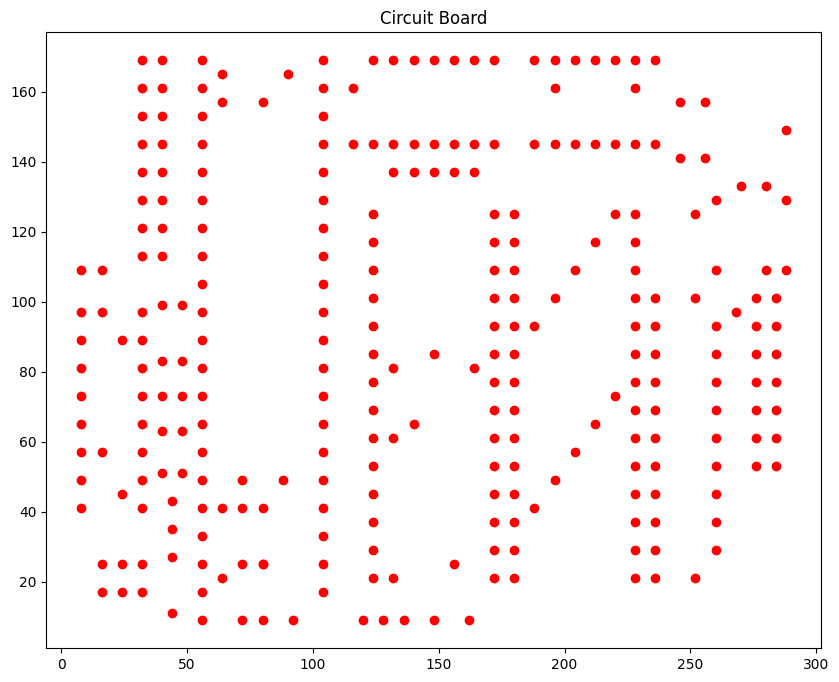

In [17]:
# Instantiate the data problem.
data = create_data_model()
circuit = pd.DataFrame(data['locations'])

f, ax = plt.subplots(figsize = [10,8])
plt.scatter(x = circuit.iloc[:,0], y = circuit.iloc[:,1], c='r')
plt.title("Circuit Board")
plt.show()

In [18]:
# Create the routing index manager.
manager = pywrapcp.RoutingIndexManager(len(data['locations']),
                                       data['num_vehicles'], data['depot'])

# Create Routing Model.
routing = pywrapcp.RoutingModel(manager)

distance_matrix = compute_euclidean_distance_matrix(data['locations'])

transit_callback_index = routing.RegisterTransitCallback(distance_callback)

# Define cost of each arc.
routing.SetArcCostEvaluatorOfAllVehicles(transit_callback_index)

# Setting first solution heuristic.
search_parameters = pywrapcp.DefaultRoutingSearchParameters()
search_parameters.first_solution_strategy = (
    routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC)

# Solve the problem.
assignment = routing.SolveWithParameters(search_parameters)

# Print solution on console.
if assignment:
    path_solution = print_solution(manager, routing, assignment)

Objective: 2784
Route:
 0 -> 1 -> 279 -> 2 -> 278 -> 277 -> 248 -> 247 -> 243 -> 242 -> 241 -> 240 -> 239 -> 238 -> 245 -> 244 -> 246 -> 249 -> 250 -> 229 -> 228 -> 231 -> 230 -> 237 -> 236 -> 235 -> 234 -> 233 -> 232 -> 227 -> 226 -> 225 -> 224 -> 223 -> 222 -> 218 -> 221 -> 220 -> 219 -> 202 -> 203 -> 204 -> 205 -> 207 -> 206 -> 211 -> 212 -> 215 -> 216 -> 217 -> 214 -> 213 -> 210 -> 209 -> 208 -> 251 -> 254 -> 255 -> 257 -> 256 -> 253 -> 252 -> 139 -> 140 -> 141 -> 142 -> 143 -> 199 -> 201 -> 200 -> 195 -> 194 -> 193 -> 191 -> 190 -> 189 -> 188 -> 187 -> 163 -> 164 -> 165 -> 166 -> 167 -> 168 -> 169 -> 171 -> 170 -> 172 -> 105 -> 106 -> 104 -> 103 -> 107 -> 109 -> 111 -> 110 -> 113 -> 114 -> 116 -> 117 -> 61 -> 62 -> 63 -> 65 -> 64 -> 84 -> 85 -> 115 -> 112 -> 86 -> 83 -> 82 -> 87 -> 81 -> 80 -> 88 -> 108 -> 89 -> 90 -> 91 -> 102 -> 101 -> 100 -> 99 -> 98 -> 97 -> 96 -> 95 -> 94 -> 93 -> 92 -> 79 -> 78 -> 77 -> 76 -> 74 -> 75 -> 73 -> 72 -> 71 -> 70 -> 69 -> 66 -> 68 -> 67 -> 57 -> 

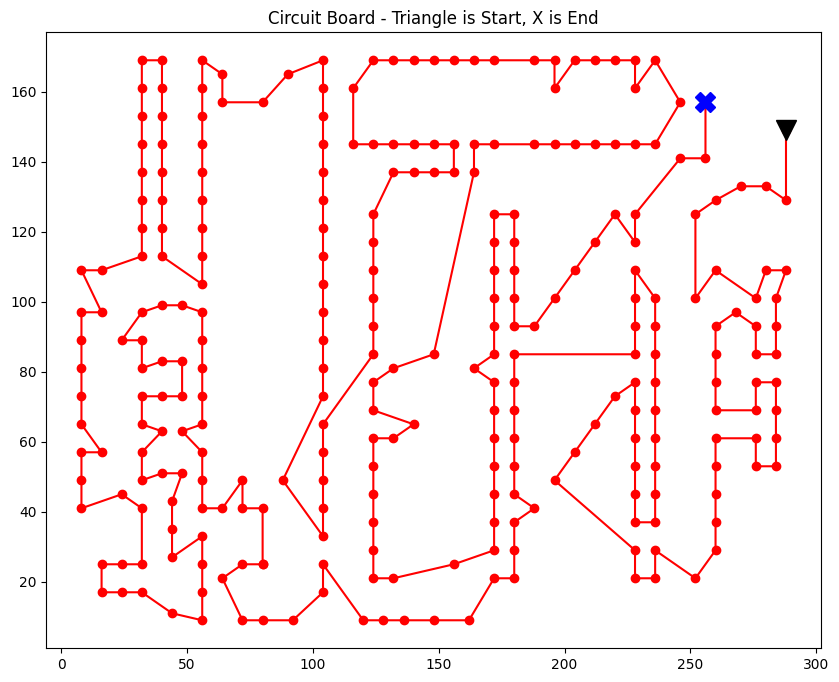

In [19]:
f, ax = plt.subplots(figsize = [10,8])
ax.plot(circuit.iloc[path_solution,0], circuit.iloc[path_solution,1], 'r-o')
ax.plot(circuit.iloc[path_solution,0][0], circuit.iloc[path_solution,1][0], 'k-v', markersize=15)
ax.plot(circuit.iloc[path_solution[-1],0], circuit.iloc[path_solution[-1],1], 'b-X', markersize=15)
plt.title("Circuit Board - Triangle is Start, X is End")
plt.show()

#### Multiple Vehicle Routing Problem

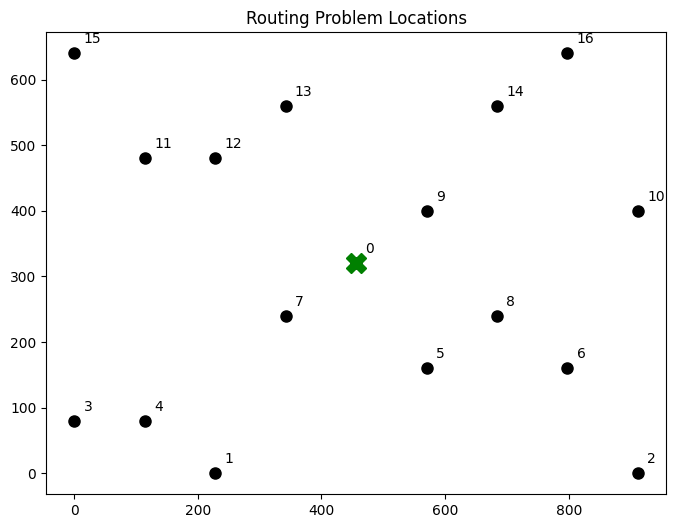

In [20]:
coordinates = [
(456, 320), # location 0 - the depot
(228, 0),    # location 1
(912, 0),    # location 2
(0, 80),     # location 3
(114, 80),   # location 4
(570, 160),  # location 5
(798, 160),  # location 6
(342, 240),  # location 7
(684, 240),  # location 8
(570, 400),  # location 9
(912, 400),  # location 10
(114, 480),  # location 11
(228, 480),  # location 12
(342, 560),  # location 13
(684, 560),  # location 14
(0, 640),    # location 15
(798, 640)]  # location 16

X = np.array([x[0] for x in coordinates])
Y = np.array([x[1] for x in coordinates])

f, ax = plt.subplots(figsize = [8,6])
for i, txt in enumerate(coordinates):
    ax.text(X[i] + 15, Y[i]+ 15, f"{i}")

ax.plot(X, Y, 'ko', markersize=8)
ax.plot(X[0], Y[0], 'gX', markersize=15)
ax.set_title("Routing Problem Locations")
plt.show()

In [21]:
"""Vehicles Routing Problem (VRP)."""

from __future__ import print_function
from ortools.constraint_solver import routing_enums_pb2
from ortools.constraint_solver import pywrapcp


def create_data_model():
    """Stores the data for the problem."""
    data = {}
    data['distance_matrix'] = [
        [
            0, 548, 776, 696, 582, 274, 502, 194, 308, 194, 536, 502, 388, 354,
            468, 776, 662
        ],
        [
            548, 0, 684, 308, 194, 502, 730, 354, 696, 742, 1084, 594, 480, 674,
            1016, 868, 1210
        ],
        [
            776, 684, 0, 992, 878, 502, 274, 810, 468, 742, 400, 1278, 1164,
            1130, 788, 1552, 754
        ],
        [
            696, 308, 992, 0, 114, 650, 878, 502, 844, 890, 1232, 514, 628, 822,
            1164, 560, 1358
        ],
        [
            582, 194, 878, 114, 0, 536, 764, 388, 730, 776, 1118, 400, 514, 708,
            1050, 674, 1244
        ],
        [
            274, 502, 502, 650, 536, 0, 228, 308, 194, 240, 582, 776, 662, 628,
            514, 1050, 708
        ],
        [
            502, 730, 274, 878, 764, 228, 0, 536, 194, 468, 354, 1004, 890, 856,
            514, 1278, 480
        ],
        [
            194, 354, 810, 502, 388, 308, 536, 0, 342, 388, 730, 468, 354, 320,
            662, 742, 856
        ],
        [
            308, 696, 468, 844, 730, 194, 194, 342, 0, 274, 388, 810, 696, 662,
            320, 1084, 514
        ],
        [
            194, 742, 742, 890, 776, 240, 468, 388, 274, 0, 342, 536, 422, 388,
            274, 810, 468
        ],
        [
            536, 1084, 400, 1232, 1118, 582, 354, 730, 388, 342, 0, 878, 764,
            730, 388, 1152, 354
        ],
        [
            502, 594, 1278, 514, 400, 776, 1004, 468, 810, 536, 878, 0, 114,
            308, 650, 274, 844
        ],
        [
            388, 480, 1164, 628, 514, 662, 890, 354, 696, 422, 764, 114, 0, 194,
            536, 388, 730
        ],
        [
            354, 674, 1130, 822, 708, 628, 856, 320, 662, 388, 730, 308, 194, 0,
            342, 422, 536
        ],
        [
            468, 1016, 788, 1164, 1050, 514, 514, 662, 320, 274, 388, 650, 536,
            342, 0, 764, 194
        ],
        [
            776, 868, 1552, 560, 674, 1050, 1278, 742, 1084, 810, 1152, 274,
            388, 422, 764, 0, 798
        ],
        [
            662, 1210, 754, 1358, 1244, 708, 480, 856, 514, 468, 354, 844, 730,
            536, 194, 798, 0
        ],
    ]
    data['num_vehicles'] = 4
    data['depot'] = 0
    return data


def print_solution(data, manager, routing, solution):
    """Prints solution on console."""
    max_route_distance = 0
    solutions = {}
    for vehicle_id in range(data['num_vehicles']):
        index = routing.Start(vehicle_id)
        plan_output = 'Route for vehicle {}:\n'.format(vehicle_id)
        route_distance = 0
        vehicle_solution = []
        while not routing.IsEnd(index):
            vehicle_solution.append(manager.IndexToNode(index))
            plan_output += ' {} -> '.format(manager.IndexToNode(index))
            previous_index = index
            index = solution.Value(routing.NextVar(index))
            route_distance += routing.GetArcCostForVehicle(
                previous_index, index, vehicle_id)
        plan_output += '{}\n'.format(manager.IndexToNode(index))
        plan_output += 'Distance of the route: {}m\n'.format(route_distance)
        print(plan_output)
        max_route_distance = max(route_distance, max_route_distance)
        solutions[vehicle_id] = vehicle_solution
    print('Maximum of the route distances: {}m'.format(max_route_distance))
    return solutions

"""Solve the CVRP problem."""
# Instantiate the data problem.
data = create_data_model()

# Create the routing index manager.
manager = pywrapcp.RoutingIndexManager(len(data['distance_matrix']),
                                       data['num_vehicles'], data['depot'])

# Create Routing Model.
routing = pywrapcp.RoutingModel(manager)


# Create and register a transit callback.
def distance_callback(from_index, to_index):
    """Returns the distance between the two nodes."""
    # Convert from routing variable Index to distance matrix NodeIndex.
    from_node = manager.IndexToNode(from_index)
    to_node = manager.IndexToNode(to_index)
    return data['distance_matrix'][from_node][to_node]

transit_callback_index = routing.RegisterTransitCallback(distance_callback)

# Define cost of each arc.
routing.SetArcCostEvaluatorOfAllVehicles(transit_callback_index)

# Add Distance constraint.
dimension_name = 'Distance'
routing.AddDimension(
    transit_callback_index,
    0,  # no slack
    3000,  # vehicle maximum travel distance
    True,  # start cumul to zero
    dimension_name)
distance_dimension = routing.GetDimensionOrDie(dimension_name)
distance_dimension.SetGlobalSpanCostCoefficient(100)

# Setting first solution heuristic.
search_parameters = pywrapcp.DefaultRoutingSearchParameters()
search_parameters.first_solution_strategy = (
    routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC)

# Solve the problem.
solution = routing.SolveWithParameters(search_parameters)

# Print solution on console.
if solution:
    solution_dict = print_solution(data, manager, routing, solution)

Route for vehicle 0:
 0 ->  9 ->  10 ->  2 ->  6 ->  5 -> 0
Distance of the route: 1712m

Route for vehicle 1:
 0 ->  16 ->  14 ->  8 -> 0
Distance of the route: 1484m

Route for vehicle 2:
 0 ->  7 ->  1 ->  4 ->  3 -> 0
Distance of the route: 1552m

Route for vehicle 3:
 0 ->  13 ->  15 ->  11 ->  12 -> 0
Distance of the route: 1552m

Maximum of the route distances: 1712m


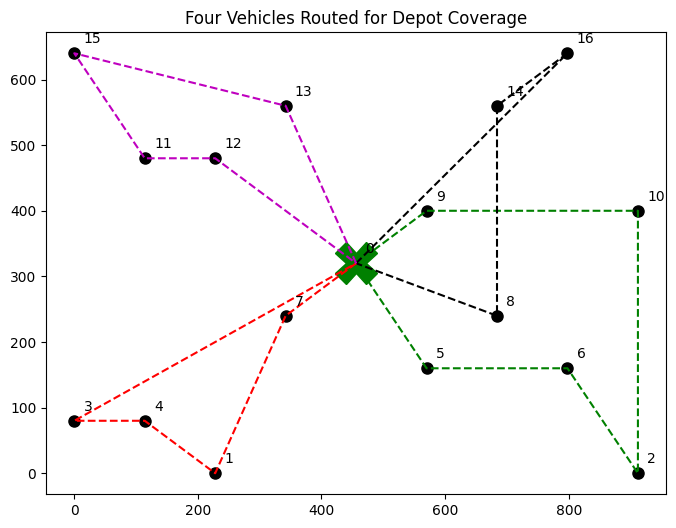

In [22]:
f, ax = plt.subplots(figsize = [8,6])

ax.plot(X, Y, 'ko', markersize=8)
ax.plot(X[0], Y[0], 'gX', markersize=30)

for i, txt in enumerate(coordinates):
    ax.text(X[i] + 15, Y[i]+ 15, f"{i}")

vehicle_colors = ["g","k","r", "m"]
for vehicle in solution_dict:
    ax.plot(X[solution_dict[vehicle] + [0]], Y[solution_dict[vehicle] + [0]], f'{vehicle_colors[vehicle]}--')
    
ax.set_title("Four Vehicles Routed for Depot Coverage")
plt.show()

## Scheduling Problem
https://developers.google.com/optimization/scheduling/employee_scheduling

- Employee Scheduling
- The Job Shop Problem

In [23]:
from ortools.sat.python import cp_model

# This program tries to find an optimal assignment of nurses to shifts
# (3 shifts per day, for 7 days), subject to some constraints (see below).
# Each nurse can request to be assigned to specific shifts.
# The optimal assignment maximizes the number of fulfilled shift requests.
num_nurses = 5
num_shifts = 3
num_days = 7
all_nurses = range(num_nurses)
all_shifts = range(num_shifts)
all_days = range(num_days)
shift_requests = [
    [[0, 0, 1], [0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 1], [0, 1, 0], [0, 0, 1]],
    [[0, 0, 0], [0, 0, 0], [0, 1, 0], [0, 1, 0], [1, 0, 0], [0, 0, 0], [0, 0, 1]],
    [[0, 1, 0], [0, 1, 0], [0, 0, 0], [1, 0, 0], [0, 0, 0], [0, 1, 0], [0, 0, 0]],
    [[0, 0, 1], [0, 0, 0], [1, 0, 0], [0, 1, 0], [0, 0, 0], [1, 0, 0], [0, 0, 0]],
    [[0, 0, 0], [0, 0, 1], [0, 1, 0], [0, 0, 0], [1, 0, 0], [0, 1, 0], [0, 0, 0]]
]
requested_df = pd.DataFrame(shift_requests)

In [24]:
# Creates the model.
model = cp_model.CpModel()

# Creates shift variables.
# shifts[(n, d, s)]: nurse 'n' works shift 's' on day 'd'.
shifts = {}
for n in all_nurses:
    for d in all_days:
        for s in all_shifts:
            shifts[(n, d,
                    s)] = model.NewBoolVar('shift_n%id%is%i' % (n, d, s))

# Each shift is assigned to exactly one nurse in .
for d in all_days:
    for s in all_shifts:
        model.Add(sum(shifts[(n, d, s)] for n in all_nurses) == 1)

# Each nurse works at most one shift per day.
for n in all_nurses:
    for d in all_days:
        model.Add(sum(shifts[(n, d, s)] for s in all_shifts) <= 1)

# Try to distribute the shifts evenly, so that each nurse works
# min_shifts_per_nurse shifts. If this is not possible, because the total
# number of shifts is not divisible by the number of nurses, some nurses will
# be assigned one more shift.
min_shifts_per_nurse = (num_shifts * num_days) // num_nurses
if num_shifts * num_days % num_nurses == 0:
    max_shifts_per_nurse = min_shifts_per_nurse
else:
    max_shifts_per_nurse = min_shifts_per_nurse + 1
for n in all_nurses:
    num_shifts_worked = 0
    for d in all_days:
        for s in all_shifts:
            num_shifts_worked += shifts[(n, d, s)]
    model.Add(min_shifts_per_nurse <= num_shifts_worked)
    model.Add(num_shifts_worked <= max_shifts_per_nurse)

# pylint: disable=g-complex-comprehension
model.Maximize(
    sum(shift_requests[n][d][s] * shifts[(n, d, s)] for n in all_nurses
        for d in all_days for s in all_shifts))
# Creates the solver and solve.
solver = cp_model.CpSolver()
solver.Solve(model)

results = {d:{} for d in all_days}
for d in all_days:
    print('Day', d)
    for n in all_nurses:
        for s in all_shifts:
            if solver.Value(shifts[(n, d, s)]) == 1:
                results[d][s] = n
                if shift_requests[n][d][s] == 1:
                    print('Nurse', n, 'works shift', s, '(requested).')
                else:
                    print('Nurse', n, 'works shift', s, '(not requested).')
    print()

print("Results - Format {day:{shift:nurse}}")
pprint.pprint(results)    

print("\nShifts per nurse?")
nurse_occurence =[]
for r in results:
    for s in results[r]:
        nurse_occurence.append(results[r][s])
print(Counter(nurse_occurence))

# Statistics.
print()
print('Statistics')
print('  - Number of shift requests met = %i' % solver.ObjectiveValue(),
      '(out of', num_nurses * min_shifts_per_nurse, ')')
print('  - wall time       : %f s' % solver.WallTime())


Day 0
Nurse 1 works shift 0 (not requested).
Nurse 2 works shift 1 (requested).
Nurse 3 works shift 2 (requested).

Day 1
Nurse 0 works shift 0 (not requested).
Nurse 2 works shift 1 (requested).
Nurse 4 works shift 2 (requested).

Day 2
Nurse 2 works shift 2 (not requested).
Nurse 3 works shift 0 (requested).
Nurse 4 works shift 1 (requested).

Day 3
Nurse 1 works shift 2 (not requested).
Nurse 2 works shift 0 (requested).
Nurse 3 works shift 1 (requested).

Day 4
Nurse 0 works shift 2 (requested).
Nurse 1 works shift 1 (not requested).
Nurse 4 works shift 0 (requested).

Day 5
Nurse 0 works shift 2 (not requested).
Nurse 2 works shift 1 (requested).
Nurse 3 works shift 0 (requested).

Day 6
Nurse 0 works shift 2 (requested).
Nurse 1 works shift 1 (not requested).
Nurse 4 works shift 0 (not requested).

Results - Format {day:{shift:nurse}}
{0: {0: 1, 1: 2, 2: 3},
 1: {0: 0, 1: 2, 2: 4},
 2: {0: 3, 1: 4, 2: 2},
 3: {0: 2, 1: 3, 2: 1},
 4: {0: 4, 1: 1, 2: 0},
 5: {0: 3, 1: 2, 2: 0},
 6:

### The Job Shop Problem

In [25]:
Image(url= "https://developers.google.com/optimization/images/scheduling/schedule1.png")

In [26]:
from __future__ import print_function

import collections

# Import Python wrapper for or-tools CP-SAT solver.
from ortools.sat.python import cp_model


def MinimalJobshopSat():
    """Minimal jobshop problem."""
    # Create the model.
    model = cp_model.CpModel()

    jobs_data = [  # task = (machine_id, processing_time).
        [(0, 3), (1, 2), (2, 2)],  # Job0
        [(0, 2), (2, 1), (1, 4)],  # Job1
        [(1, 4), (2, 3)]  # Job2
    ]

    machines_count = 1 + max(task[0] for job in jobs_data for task in job)
    all_machines = range(machines_count)

    # Computes horizon dynamically as the sum of all durations.
    horizon = sum(task[1] for job in jobs_data for task in job)

    # Named tuple to store information about created variables.
    task_type = collections.namedtuple('task_type', 'start end interval')
    # Named tuple to manipulate solution information.
    assigned_task_type = collections.namedtuple('assigned_task_type',
                                                'start job index duration')

    # Creates job intervals and add to the corresponding machine lists.
    all_tasks = {}
    machine_to_intervals = collections.defaultdict(list)

    for job_id, job in enumerate(jobs_data):
        for task_id, task in enumerate(job):
            machine = task[0]
            duration = task[1]
            suffix = '_%i_%i' % (job_id, task_id)
            start_var = model.NewIntVar(0, horizon, 'start' + suffix)
            end_var = model.NewIntVar(0, horizon, 'end' + suffix)
            interval_var = model.NewIntervalVar(start_var, duration, end_var,
                                                'interval' + suffix)
            all_tasks[job_id, task_id] = task_type(
                start=start_var, end=end_var, interval=interval_var)
            machine_to_intervals[machine].append(interval_var)

    # Create and add disjunctive constraints.
    for machine in all_machines:
        model.AddNoOverlap(machine_to_intervals[machine])

    # Precedences inside a job.
    for job_id, job in enumerate(jobs_data):
        for task_id in range(len(job) - 1):
            model.Add(all_tasks[job_id, task_id +
                                1].start >= all_tasks[job_id, task_id].end)

    # Makespan objective.
    obj_var = model.NewIntVar(0, horizon, 'makespan')
    model.AddMaxEquality(obj_var, [
        all_tasks[job_id, len(job) - 1].end
        for job_id, job in enumerate(jobs_data)
    ])
    model.Minimize(obj_var)

    # Solve model.
    solver = cp_model.CpSolver()
    status = solver.Solve(model)

    if status == cp_model.OPTIMAL:
        # Create one list of assigned tasks per machine.
        assigned_jobs = collections.defaultdict(list)
        for job_id, job in enumerate(jobs_data):
            for task_id, task in enumerate(job):
                machine = task[0]
                assigned_jobs[machine].append(
                    assigned_task_type(
                        start=solver.Value(all_tasks[job_id, task_id].start),
                        job=job_id,
                        index=task_id,
                        duration=task[1]))

        # Create per machine output lines.
        output = ''
        for machine in all_machines:
            # Sort by starting time.
            assigned_jobs[machine].sort()
            sol_line_tasks = 'Machine ' + str(machine) + ': '
            sol_line = '           '

            for assigned_task in assigned_jobs[machine]:
                name = 'job_%i_%i' % (assigned_task.job, assigned_task.index)
                # Add spaces to output to align columns.
                sol_line_tasks += '%-10s' % name

                start = assigned_task.start
                duration = assigned_task.duration
                sol_tmp = '[%i,%i]' % (start, start + duration)
                # Add spaces to output to align columns.
                sol_line += '%-10s' % sol_tmp

            sol_line += '\n'
            sol_line_tasks += '\n'
            output += sol_line_tasks
            output += sol_line

        # Finally print the solution found.
        print('Optimal Schedule Length: %i' % solver.ObjectiveValue())
        print(output)

MinimalJobshopSat()

Optimal Schedule Length: 11
Machine 0: job_1_0   job_0_0   
           [0,2]     [2,5]     
Machine 1: job_2_0   job_0_1   job_1_2   
           [0,4]     [5,7]     [7,11]    
Machine 2: job_1_1   job_2_1   job_0_2   
           [2,3]     [4,7]     [7,9]     



## Network Flow Problem

https://developers.google.com/optimization/flow/maxflow

**Maximum Flows:** <br>
Get from Node 0 to 4, while maximizing total flow in a unit of time. How to use a networks full capacity.

- At each node, other than the source or the sink, the total flow of all arcs leading in to the node equals the total flow of all arcs leading out of it.

In [27]:
%%html
<svg xmlns="http://www.w3.org/2000/svg" xmlns:xlink="http://www.w3.org/1999/xlink" width="700" height="450">
<!-- arcs -->
<line x1="50" y1="225" x2="250" y2="25" stroke="#762a83" stroke-width="3"></line>
<line x1="50" y1="225" x2="250" y2="225" stroke="#762a83" stroke-width="3"></line>
<line x1="50" y1="225" x2="250" y2="425" stroke="#762a83" stroke-width="3"></line>
<line x1="250" y1="25" x2="250" y2="225" stroke="#762a83" stroke-width="3"></line>
<line x1="250" y1="225" x2="450" y2="225" stroke="#762a83" stroke-width="3"></line>
<line x1="250" y1="25" x2="450" y2="225" stroke="#762a83" stroke-width="3"></line>
<line x1="250" y1="225" x2="450" y2="225" stroke="#762a83" stroke-width="3"></line>
<line x1="250" y1="425" x2="450" y2="225" stroke="#762a83" stroke-width="3"></line>
<g stroke="#762a83" stroke-width="3" fill="none">
      <path d="M 250 425 a 50 155 0 0 1 0 -200"></path> <!-- node 3 to 2 -->
      <path d="M 250 425 a 50 155 0 0 0 0 -200"></path> <!-- node 2 to 3 -->
</g>
<!-- weights -->
<text x="120" y="120" font-family="Verdana" font-size="18" stroke="#762a83">20</text>
<text x="143" y="215" font-family="Verdana" font-size="18" stroke="#762a83">30</text>
<text x="260" y="150" font-family="Verdana" font-size="18" stroke="#762a83">40</text>
<text x="355" y="119" font-family="Verdana" font-size="18" stroke="#762a83">30</text>
<text x="330" y="215" font-family="Verdana" font-size="18" stroke="#762a83">20</text>
<text x="120" y="350" font-family="Verdana" font-size="18" stroke="#762a83">10</text>
<text x="355" y="350" font-family="Verdana" font-size="18" stroke="#762a83">20</text>
<text x="212" y="329" font-family="Verdana" font-size="18" stroke="#762a83">5</text>
<text x="274" y="329" font-family="Verdana" font-size="18" stroke="#762a83">10</text>
<!-- arrows -->
<g stroke="#762a83" stroke-width="1" fill="#762a83">
   <path d="M 230 40 L 248 27 L 236 46 L 230 40"></path> <!-- node 0 to 1 -->
   <path d="M 228 221 L 250 225 L 228 229 L 228 220"></path> <!-- node 0 to 2 -->
   <path d="M 230 410 L 250 425 L 236 404 L 230 410"></path> <!-- node 0 to 3 -->
   <path d="M 428 221 L 450 225 L 428 229 L 428 220"></path> <!-- node 2 to 4 -->
   <path d="M 430 212 L 450 225 L 438 206 L 430 212"></path> <!-- node 1 to 4 -->
   <path d="M 432 235 L 450 225 L 439 242 L 432 235"></path> <!-- node 3 to 4 -->
   <path d="M 245 203 L 250 220 L 255 203 L 245 203"></path> <!-- node 1 to 2 -->
   <path d="M 250 403 L 251 420 L 259 406 L 250 403"></path> <!-- node 2 to 3 -->
   <path d="M 241 245 L 249 228 L 249 248 L 241 245"></path> <!-- node 3 to 2 -->
</g>
<!-- nodes -->
<g><ellipse fill="#e7d4e8" cx="50" cy="225" rx="8" ry="8" stroke="#762a83"></ellipse></g>
<g><ellipse fill="#e7d4e8" cx="250" cy="25" rx="8" ry="8" stroke="#762a83"></ellipse></g>
<g><ellipse fill="#e7d4e8" cx="250" cy="225" rx="8" ry="8" stroke="#762a83"></ellipse></g>
<g><ellipse fill="#e7d4e8" cx="450" cy="225" rx="8" ry="8" stroke="#762a83"></ellipse></g>
<g><ellipse fill="#e7d4e8" cx="250" cy="425" rx="8" ry="8" stroke="#762a83"></ellipse></g>
<!-- numbers -->
<text x="46" y="229" font-family="Verdana" font-size="12" stroke="#762a83">0</text>
<text x="246" y="29" font-family="Verdana" font-size="12" stroke="#762a83">1</text>
<text x="246" y="229" font-family="Verdana" font-size="12" stroke="#762a83">2</text>
<text x="246" y="429" font-family="Verdana" font-size="12" stroke="#762a83">3</text>
<text x="446" y="229" font-family="Verdana" font-size="12" stroke="#762a83">4</text>
</svg>

In [28]:
"""From Taha 'Introduction to Operations Research', example 6.4-2."""

from ortools.graph.python import max_flow

def main():
    """MaxFlow simple interface example."""
    start_nodes = [0, 0, 0, 1, 1, 2, 2, 3, 3]
    end_nodes = [1, 2, 3, 2, 4, 3, 4, 2, 4]
    capacities = [20, 30, 10, 40, 30, 10, 20, 5, 20]

    smf = max_flow.SimpleMaxFlow()
    for i in range(len(start_nodes)):
        smf.add_arc_with_capacity(start_nodes[i], end_nodes[i], capacities[i])

    if smf.solve(0, 4) == smf.OPTIMAL:
        print('Max flow:', smf.optimal_flow())
        print()
        print('  Arc    Flow / Capacity')
        for i in range(smf.num_arcs()):
            print('%1s -> %1s   %3s  / %3s' % (smf.tail(i), smf.head(i), smf.flow(i), smf.capacity(i)))
        print('Source side min-cut:', smf.get_source_side_min_cut())
        print('Sink side min-cut:', smf.get_sink_side_min_cut())
    else:
        print('There was an issue with the max flow input.')

main()


Max flow: 60

  Arc    Flow / Capacity
0 -> 1    20  /  20
0 -> 2    30  /  30
0 -> 3    10  /  10
1 -> 2     0  /  40
1 -> 4    20  /  30
2 -> 3    10  /  10
2 -> 4    20  /  20
3 -> 2     0  /   5
3 -> 4    20  /  20
Source side min-cut: [0]
Sink side min-cut: [4, 1]


**Minimum Flows:** <br>
Minimize the cost of using a network to achieve destination

- At a supply node, a positive amount — the supply — is added to the flow. A supply could represent production at that node, for example.
- At a demand node, a negative amount — the demand — is taken away from the flow. A demand could represent consumption at that node, for example.
- The graph below shows a min cost flow problem. The arcs are labeled with pairs of numbers: the first number is the capacity and the second number is the cost. The numbers in parentheses next to the nodes represent supplies or demands. Node 0 is a supply node with supply 20, while nodes 3 and 4 are demand nodes, with demands -5 and -15, respectively.

In [29]:
%%html
<svg xmlns="http://www.w3.org/2000/svg" xmlns:xlink="http://www.w3.org/1999/xlink" width="700" height="450">
<defs>
    <marker id="markerArrow" markerWidth="13" markerHeight="13" refX="2" refY="5" orient="auto">
        <path d="M2,2 L2,8 L12,5 L2,2" style="fill: #762a83;"></path>
    </marker>
</defs>
<line x1="50" y1="225" x2="250" y2="75" stroke="#762a83" stroke-width="3"></line> <!-- node 0 to 1 -->
<line x1="50" y1="225" x2="250" y2="375" stroke="#762a83" stroke-width="3"></line> <!-- node 0 to 2 -->
<line x1="250" y1="75" x2="250" y2="375" stroke="#762a83" stroke-width="3"></line> <!-- node 1 to 4 -->
<line x1="250" y1="75" x2="550" y2="375" stroke="#762a83" stroke-width="3"></line> <!-- node 1 to 2 -->
<line x1="250" y1="75" x2="550" y2="75" stroke="#762a83" stroke-width="3"></line> <!-- node 1 to 3 -->
<line x1="250" y1="375" x2="550" y2="75" stroke="#762a83" stroke-width="3"></line> <!-- node 2 to 3 -->
<line x1="550" y1="75" x2="550" y2="375" stroke="#762a83" stroke-width="3"></line> <!-- node 3 to 4 -->
<g stroke="#762a83" stroke-width="3" fill="none">
  <path d="M 250 375 Q 400 405, 550 375"></path> <!-- node 3 to 4 -->
  <path d="M 550 375 Q 400 345, 250 375"></path> <!-- node 4 to 3 -->
</g>
<!-- weights -->
<text x="90" y="135" font-family="Verdana" font-size="18" stroke="#762a83">(15, 4)</text>
<text x="175" y="215" font-family="Verdana" font-size="18" stroke="#762a83">(20, 2)</text>
<text x="455" y="270" font-family="Verdana" font-size="18" stroke="#762a83">(10, 6)</text>
<text x="370" y="65" font-family="Verdana" font-size="18" stroke="#762a83">(4, 2)</text>
<text x="280" y="270" font-family="Verdana" font-size="18" stroke="#762a83">(15, 1)</text>
<text x="90" y="315" font-family="Verdana" font-size="18" stroke="#762a83">(8, 4)</text>
<text x="370" y="350" font-family="Verdana" font-size="18" stroke="#762a83">(5, 3)</text>
<text x="370" y="410" font-family="Verdana" font-size="18" stroke="#762a83">(4, 3)</text>
<text x="560" y="215" font-family="Verdana" font-size="18" stroke="#762a83">(20, 2)</text>
<!-- supplies -->
<text x="0" y="228" font-family="Verdana" font-size="18" stroke="#762a83">(20)</text>
<text x="236" y="58" font-family="Verdana" font-size="18" stroke="#762a83">(0)</text>
<text x="236" y="402" font-family="Verdana" font-size="18" stroke="#762a83">(0)</text>
<text x="560" y="78" font-family="Verdana" font-size="18" stroke="#762a83">(-5)</text>
<text x="560" y="378" font-family="Verdana" font-size="18" stroke="#762a83">(-15)</text>
<!-- arrows -->
<g stroke="#762a83" stroke-width="2" fill="#762a83">
   <path d="M 50 225 L 230 90" style="marker-end: url(#markerArrow);"></path> <!-- node 0 to 1 -->
   <path d="M 50 225 L 230 360" style="marker-end: url(#markerArrow);"></path> <!-- node 0 to 2 -->
   <path d="M 250 75 L 525 75" style="marker-end: url(#markerArrow);"></path> <!-- node 1 to 3 -->
   <path d="M 250 75 L 533 358" style="marker-end: url(#markerArrow);"></path> <!-- node 1 to 4 -->
   <path d="M 250 375 L 533 92" style="marker-end: url(#markerArrow);"></path> <!-- node 2 to 3 -->
   <path d="M 250 75 L 250 350" style="marker-end: url(#markerArrow);"></path> <!-- node 1 to 2 -->
   <path d="M 550 75 L 550 350" style="marker-end: url(#markerArrow);"></path> <!-- node 3 to 4 -->
   <path d="M 250 375 Q 400 405, 525 380" fill="none" style="marker-end: url(#markerArrow);"></path>
   <!-- node 2 to 4 -->
   <path d="M 550 375 Q 400 345, 275 370" fill="none" style="marker-end: url(#markerArrow);"></path>
   <!-- node 4 to 2 -->
</g>
<!-- nodes -->
<g><ellipse fill="#e7d4e8" cx="50" cy="225" rx="8" ry="8" stroke="#762a83"></ellipse></g>
<g><ellipse fill="#e7d4e8" cx="250" cy="75" rx="8" ry="8" stroke="#762a83"></ellipse></g>
<g><ellipse fill="#e7d4e8" cx="250" cy="375" rx="8" ry="8" stroke="#762a83"></ellipse></g>
<g><ellipse fill="#e7d4e8" cx="550" cy="75" rx="8" ry="8" stroke="#762a83"></ellipse></g>
<g><ellipse fill="#e7d4e8" cx="550" cy="375" rx="8" ry="8" stroke="#762a83"></ellipse></g>
<!-- numbers -->
<text x="46" y="229" font-family="Verdana" font-size="12" stroke="#762a83">0</text>
<text x="246" y="79" font-family="Verdana" font-size="12" stroke="#762a83">1</text>
<text x="246" y="379" font-family="Verdana" font-size="12" stroke="#762a83">2</text>
<text x="546" y="79" font-family="Verdana" font-size="12" stroke="#762a83">3</text>
<text x="546" y="379" font-family="Verdana" font-size="12" stroke="#762a83">4</text>
</svg>

In [30]:
# """From Bradley, Hax, and Magnanti, 'Applied Mathematical Programming', figure 8.1."""

from ortools.graph.python import min_cost_flow

def main():
    """MinCostFlow simple interface example."""
    start_nodes = [0, 0,  1, 1,  1,  2, 2,  3, 4]
    end_nodes =   [1, 2,  2, 3,  4,  3, 4,  4, 2]
    capacities =  [15, 8, 20, 4, 10, 15, 4, 20, 5]
    unit_costs =  [4, 4,  2, 2,  6,  1, 3,  2, 3]
    supplies = [20, 0, 0, -5, -15]

    mcf = min_cost_flow.SimpleMinCostFlow()
    for i in range(len(start_nodes)):
        mcf.add_arc_with_capacity_and_unit_cost(start_nodes[i], end_nodes[i], capacities[i], unit_costs[i])
    for i in range(len(supplies)):
        mcf.set_node_supply(i, supplies[i])

    if mcf.solve() == mcf.OPTIMAL:
        print('Minimum cost:', mcf.optimal_cost())
        print()
        print('  Arc    Flow / Capacity  Cost')
        for i in range(mcf.num_arcs()):
            cost = mcf.flow(i) * mcf.unit_cost(i)
            print('%1s -> %1s   %3s  / %3s       %3s' % (
                mcf.tail(i), mcf.head(i), mcf.flow(i), mcf.capacity(i), cost))
    else:
        print('There was an issue with the min cost flow input.')

main()


Minimum cost: 150

  Arc    Flow / Capacity  Cost
0 -> 1    12  /  15        48
0 -> 2     8  /   8        32
1 -> 2     8  /  20        16
1 -> 3     4  /   4         8
1 -> 4     0  /  10         0
2 -> 3    12  /  15        12
2 -> 4     4  /   4        12
3 -> 4    11  /  20        22
4 -> 2     0  /   5         0


In [31]:
print("Notebook Runtime: %0.2f Minutes"%((time.time() - start)/60))

Notebook Runtime: 0.14 Minutes
